In [1]:
from gymnasium.wrappers import TimeLimit

from src.model.cnn import CustomCNN, CustomCNN_2
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import (
    DummyVecEnv, 
    VecNormalize,
    VecFrameStack, 
    VecTransposeImage
)

from src.mygym.lunar_lander import MyLunarLander
from src.wrapper.visual_wrapper import VisualWrapper
from src.wrapper.pendulum_wrapper import ResizeObservation


In [2]:
def make_env(seed, **kwargs):
    def _init():
        env = MyLunarLander(
                        render_mode="rgb_array", 
                        continuous=True
                        )
        # env = LoggingWrapper(env)  # For debugging: log each step. Comment out by default
        env = VisualWrapper(env)
        env = TimeLimit(env, max_episode_steps=kwargs.get("episode_timesteps"))
        env = ResizeObservation(env, 
                                (kwargs.get("image_height"), 
                                 kwargs.get("image_width")))
        env.reset(seed=seed)
        return env
    return _init

In [3]:
config = {
    "episode_timesteps": 1024,
    "image_height": 128,
    "image_width": 128,
    "n_stacked_frame": 4
}

env = DummyVecEnv([make_env(0, **config)])
# env = VecFrameStack(env, n_stack=config.get("n_stacked_frame"))
env = VecTransposeImage(env)
env = VecNormalize(env, norm_obs=False, norm_reward=True, clip_obs=10.0)

In [4]:
obs = env.reset()
obs.shape

(1, 3, 128, 128)

In [5]:
import numpy as np

np.squeeze(obs).shape

(3, 128, 128)

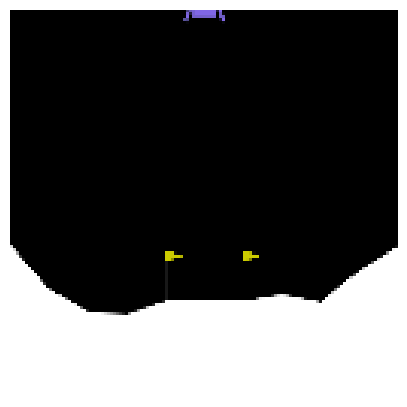

In [6]:
import matplotlib.pyplot as plt

def plot_obs(obs, title="", n_frame=4):
    if n_frame == 1:
        fig, ax = plt.subplots(figsize=(5, 6))
        tmp_obs = np.squeeze(obs)
        ax.set_title(title)
        tmp_img = tmp_obs.transpose(1, 2, 0).astype(int)
        ax.imshow(tmp_img)
        ax.axis("off")
    else:    
        fig, axes = plt.subplots(1, n_frame, figsize=(10, 5))

        tmp_obs = np.squeeze(obs)

        axes[0].set_title(title)
        for id, ax in enumerate(axes):
            tmp_img = tmp_obs[id*3: id*3+3, :, :].transpose(1, 2, 0).astype(int)
            ax.imshow(tmp_img)
            ax.axis("off")
    
plot_obs(obs, n_frame=1)

In [7]:
import pandas as pd

log_fn = "../../run/ppo_vislunarlander_default/logs/ppo_vislunarlander_eval_default_seed_42.pkl"

with open(log_fn, "rb") as f:
    df = pd.read_pickle(f)
df

,state,action,reward,accumulated_reward
0,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.28284067, -0.43254533]]",[1.1449804],[1.1449804]
1,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.34886667, 0.057557017]]",[1.1880542],[2.3330345]
2,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.09846494, 0.1030826]]",[1.1647744],[3.497809]
3,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[0.43100917, -0.08470961]]",[-3.36916],[0.128649]
4,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.07618734, -0.13845983]]",[1.1672844],[1.2959334]
...,...,...,...,...
122,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.08112675, -0.23739061]]",[-3.260426],[-54.17409]
123,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.0017189942, -0.31999546]]",[-2.5492606],[-56.72335]
124,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.6849271, -0.21847448]]",[9.489929],[-47.23342]
125,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.15278693, -0.08767452]]",[7.265728],[-39.967693]


/tmp/ipykernel_1183072/1699284908.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 6))


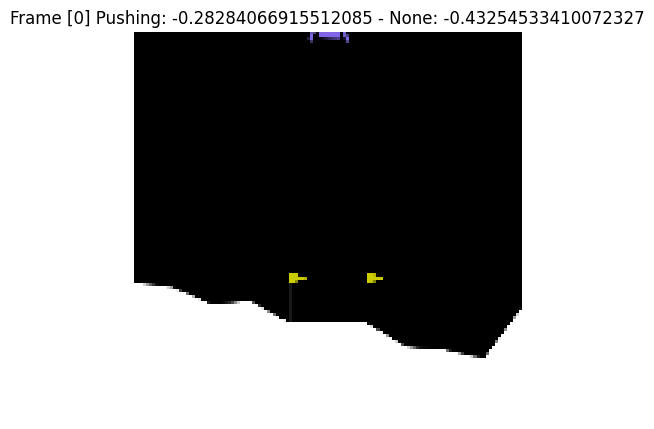

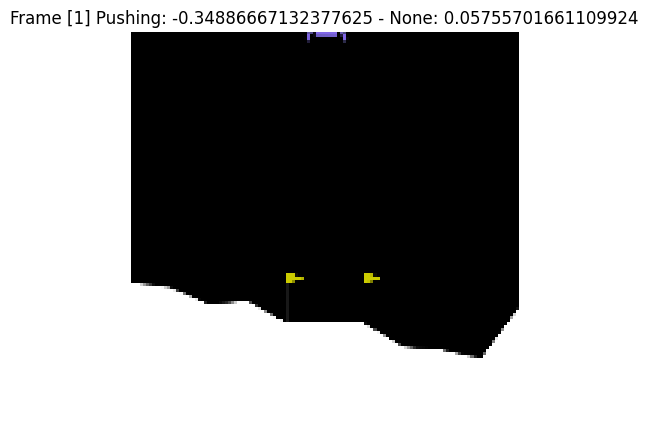

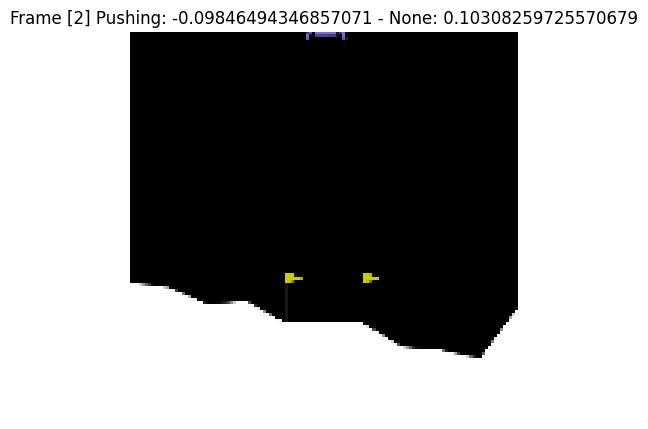

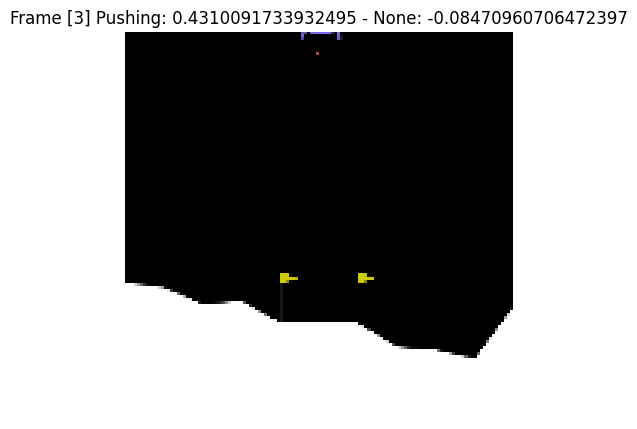

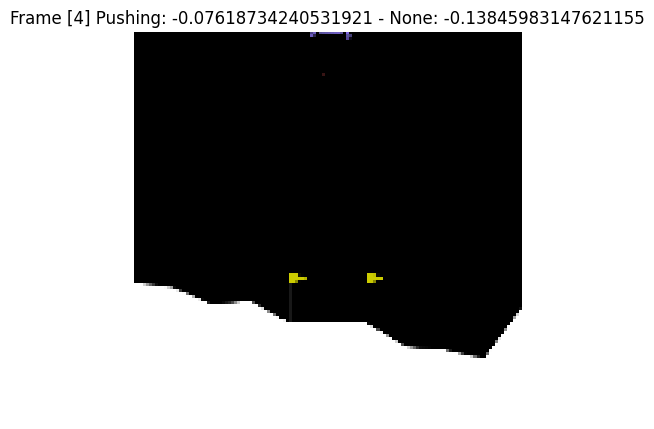

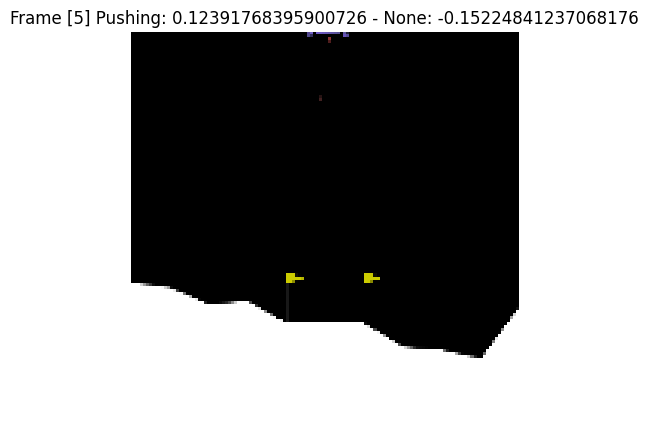

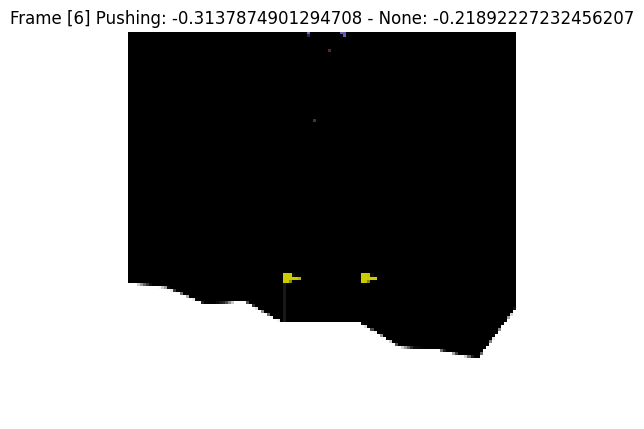

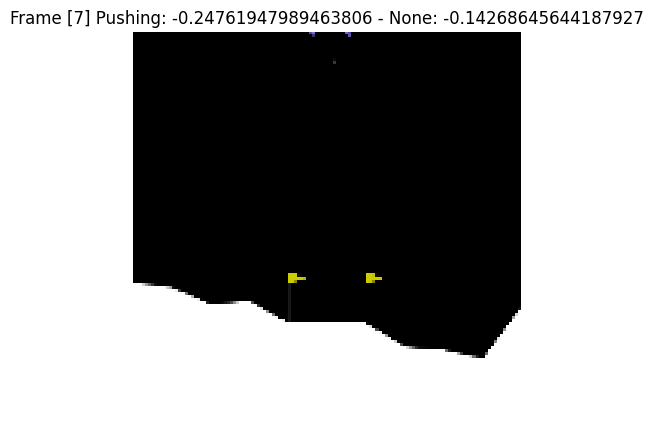

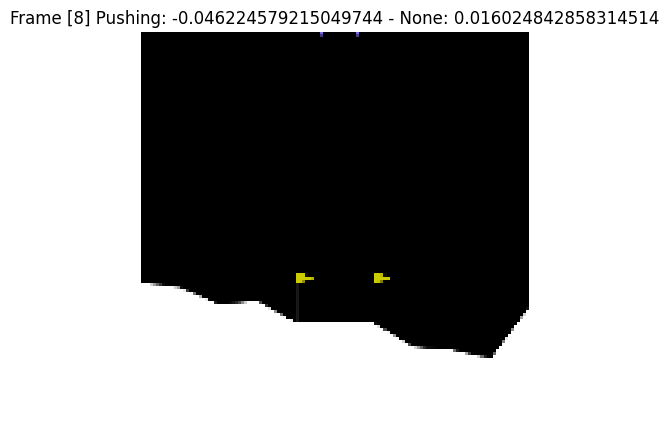

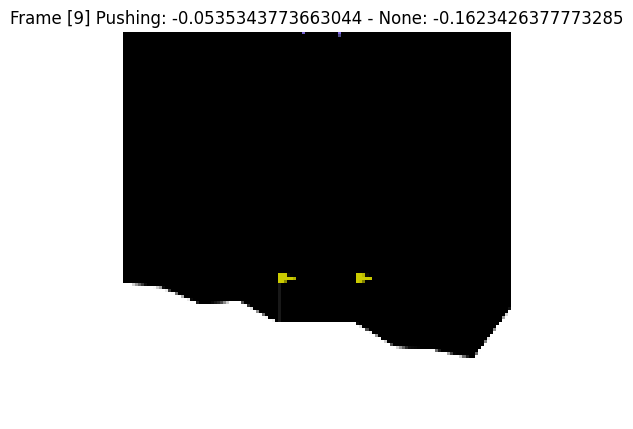

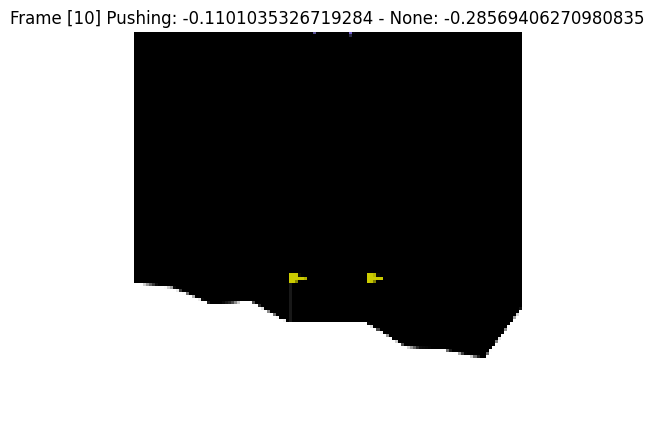

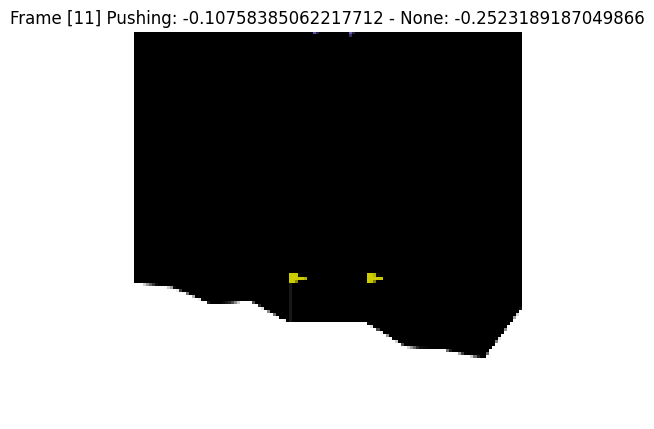

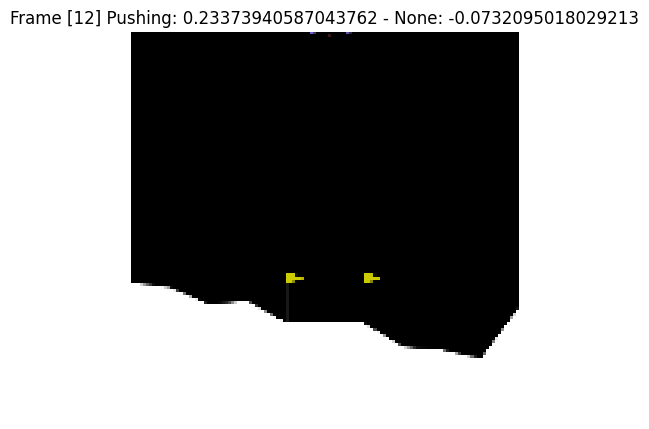

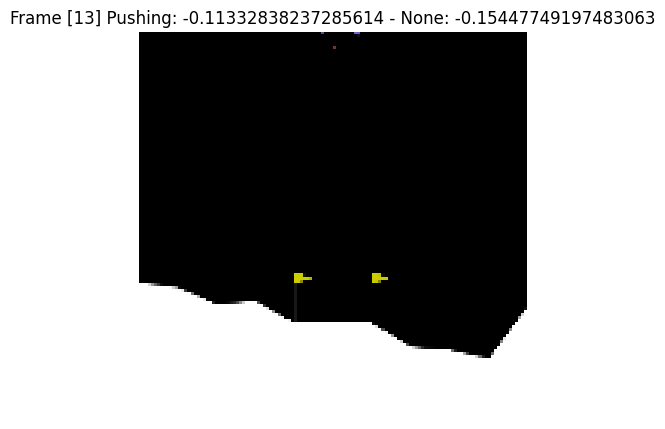

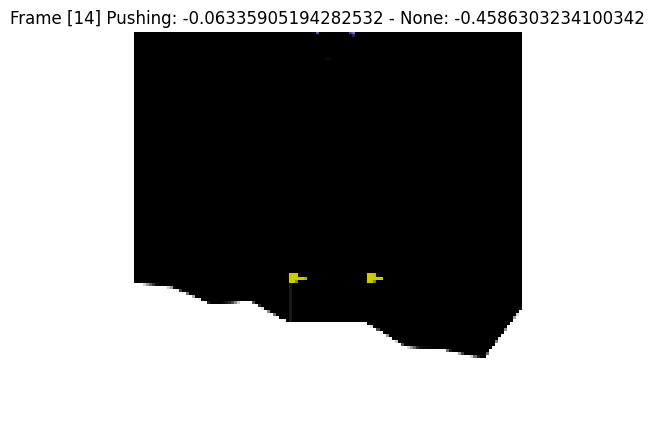

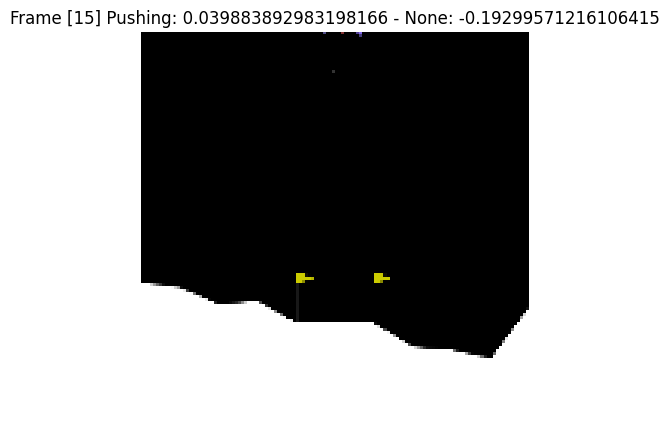

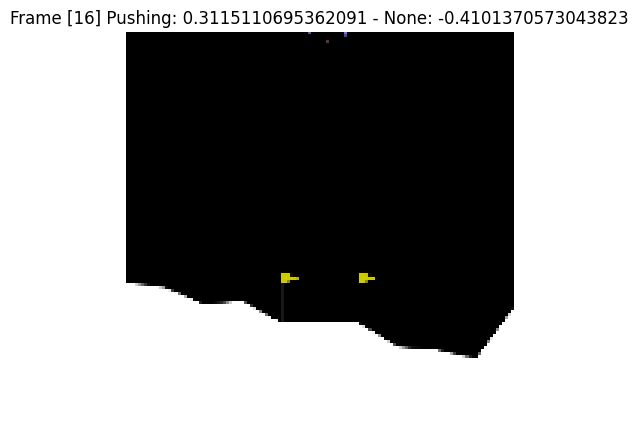

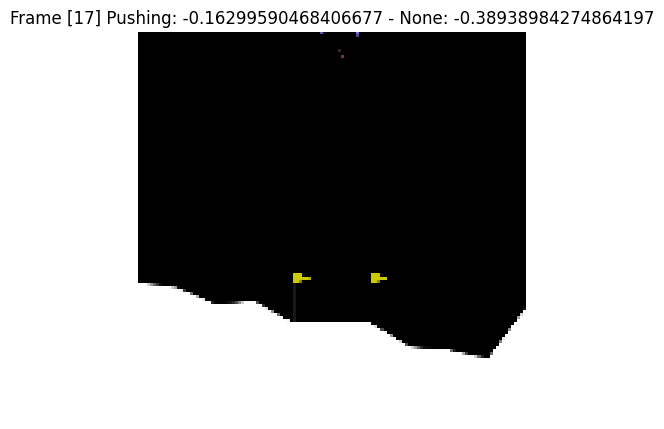

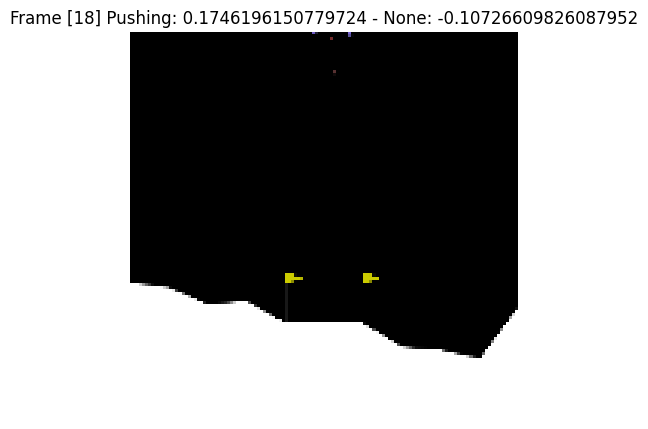

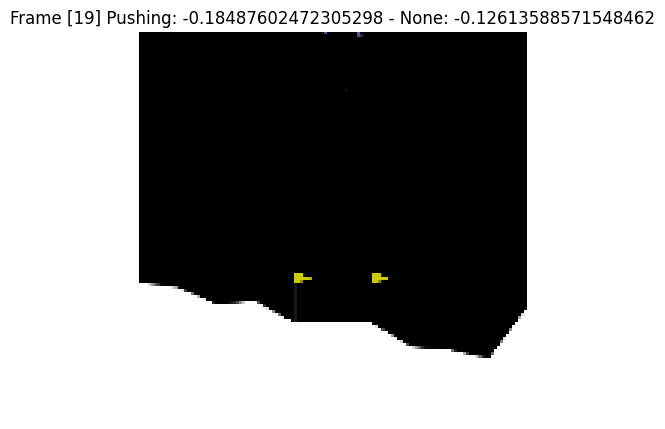

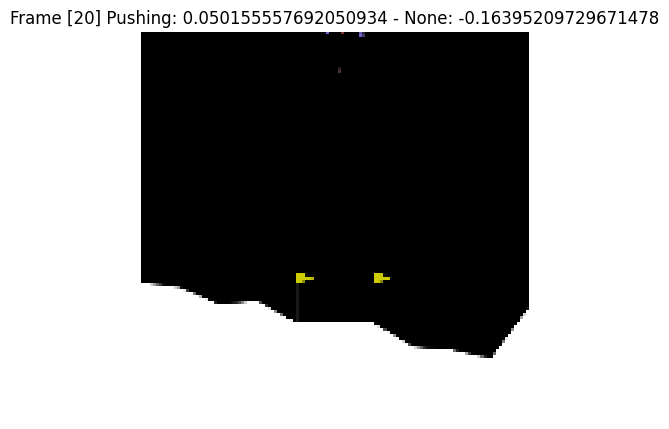

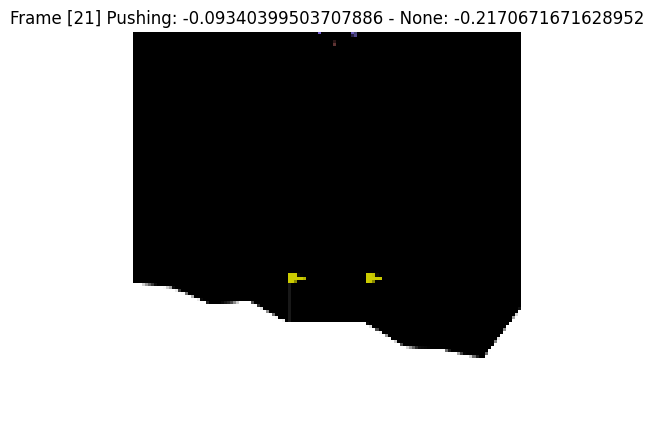

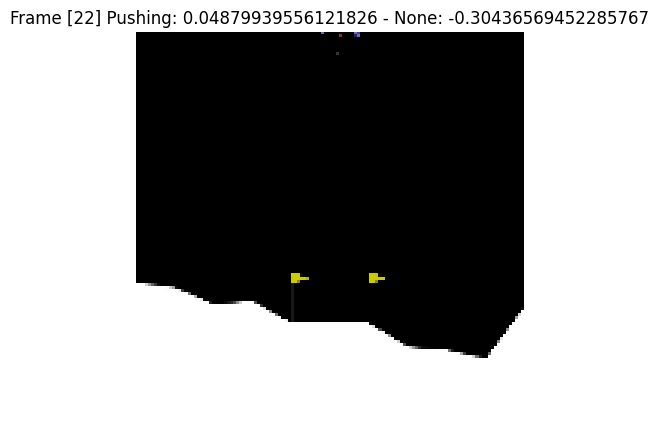

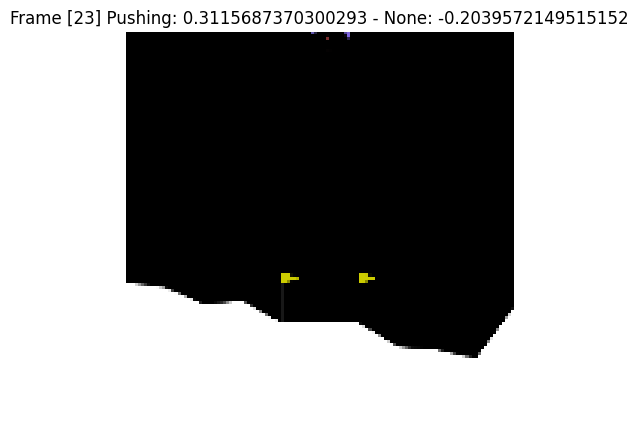

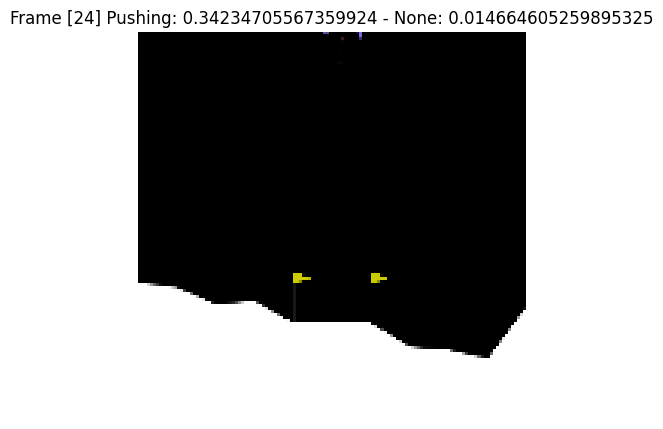

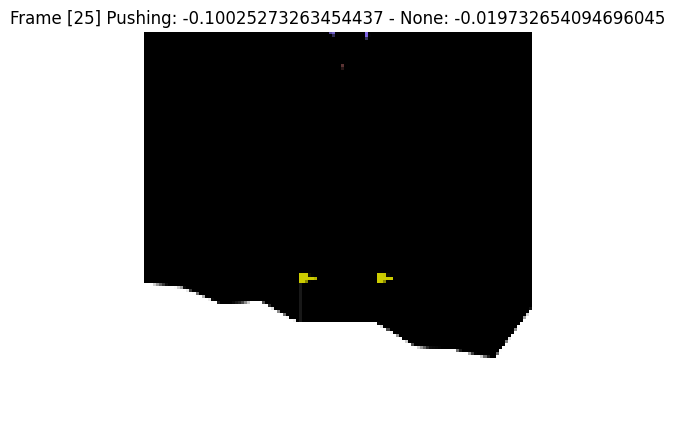

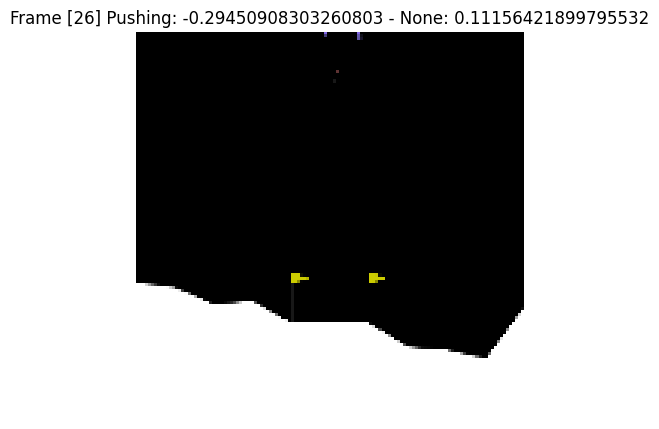

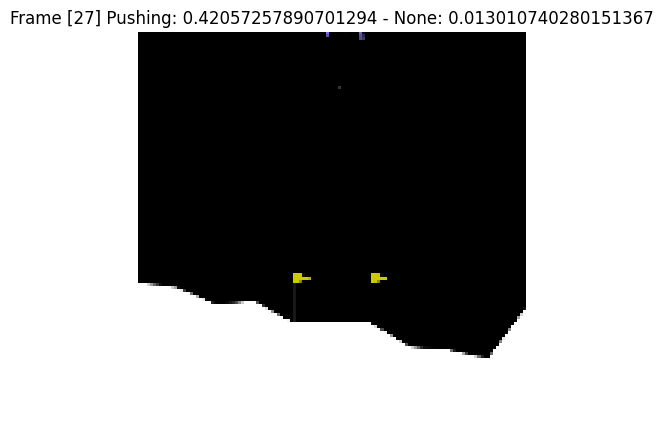

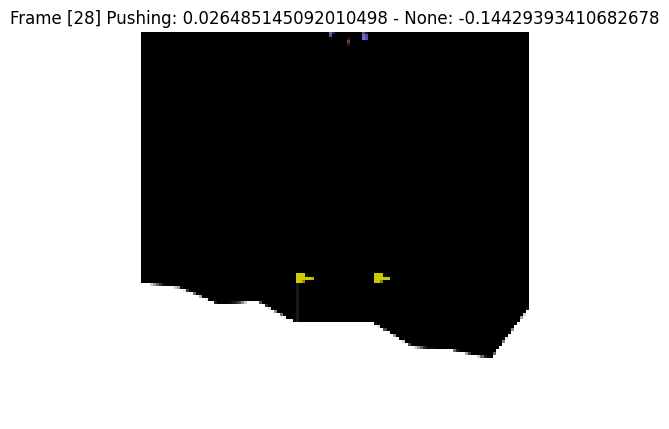

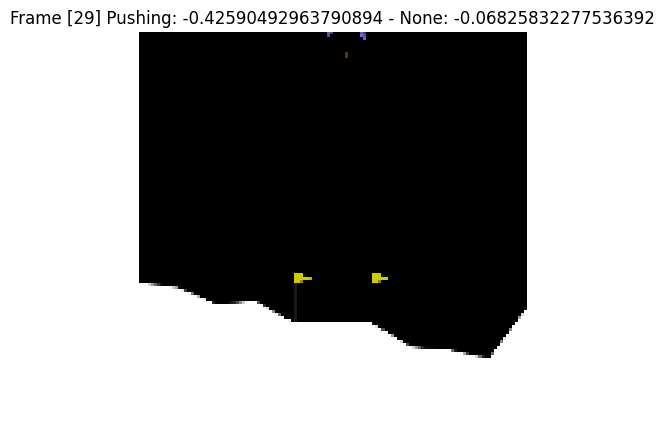

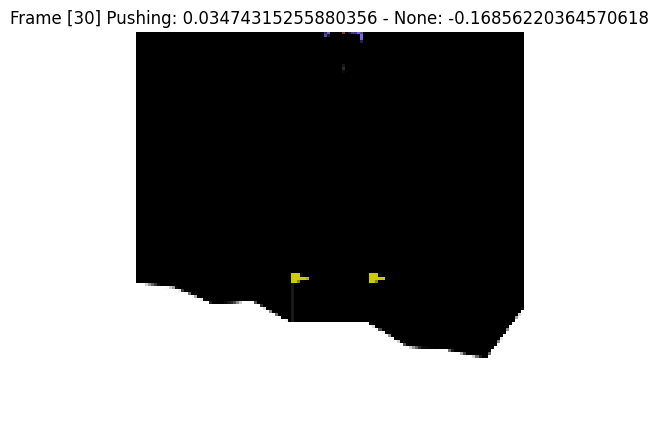

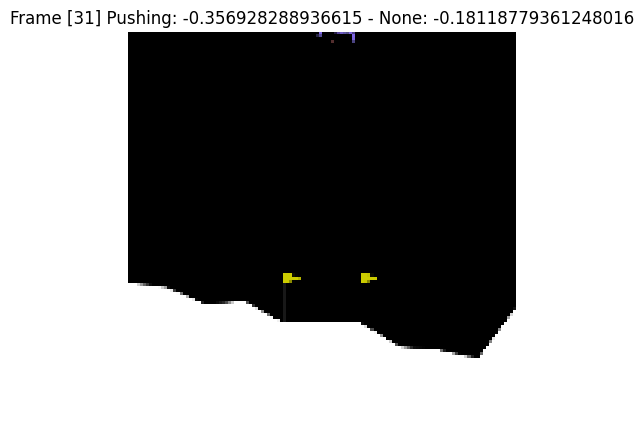

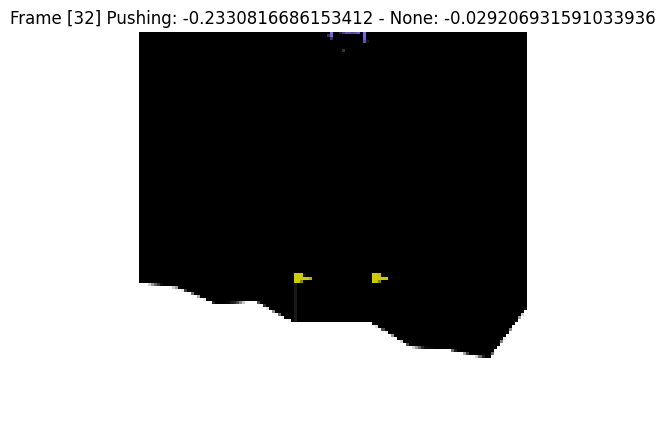

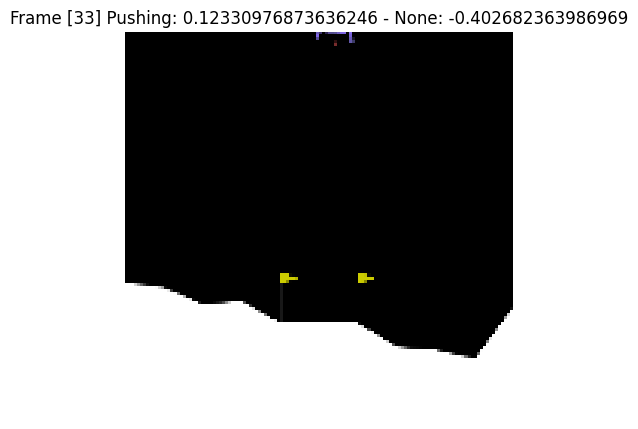

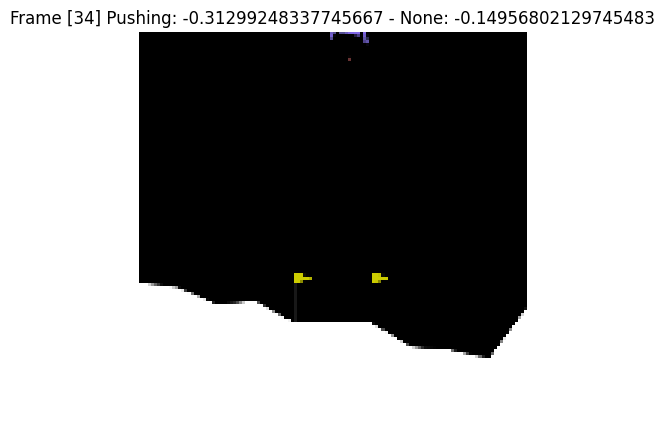

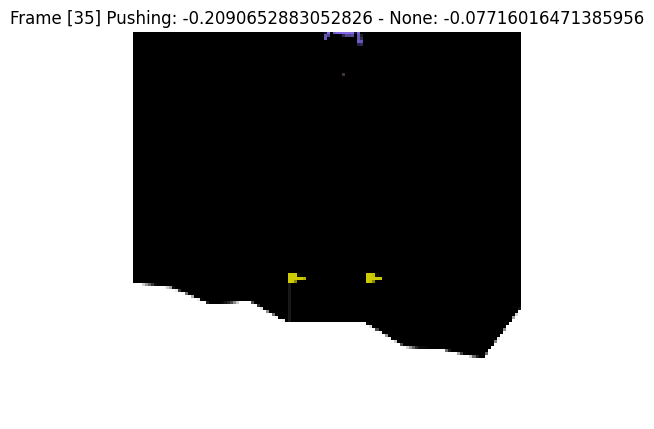

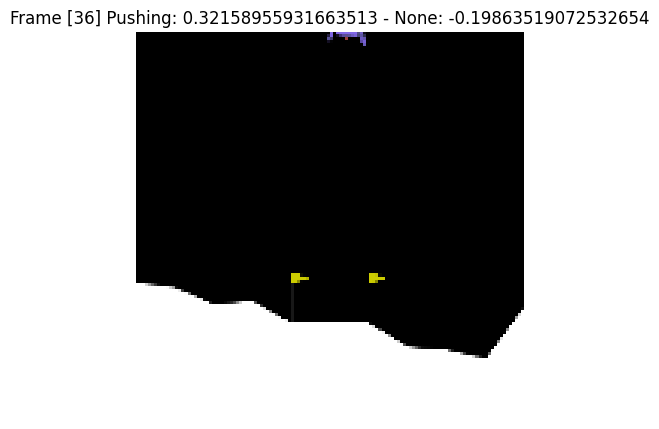

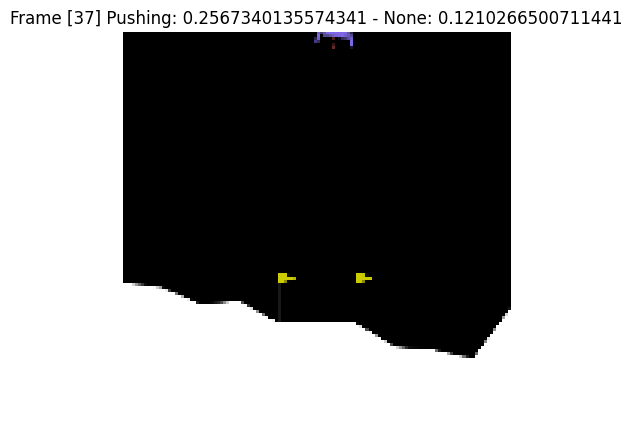

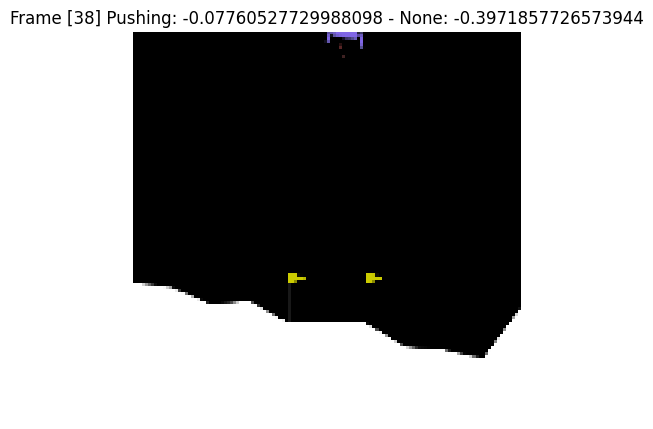

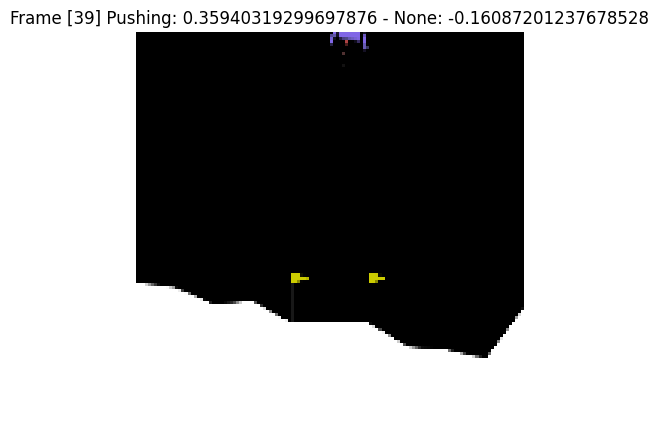

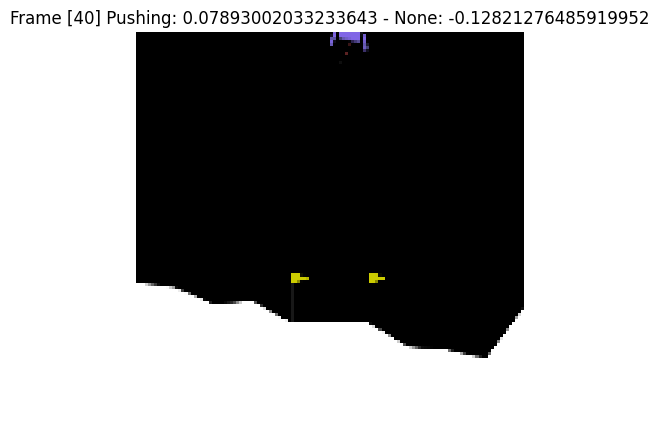

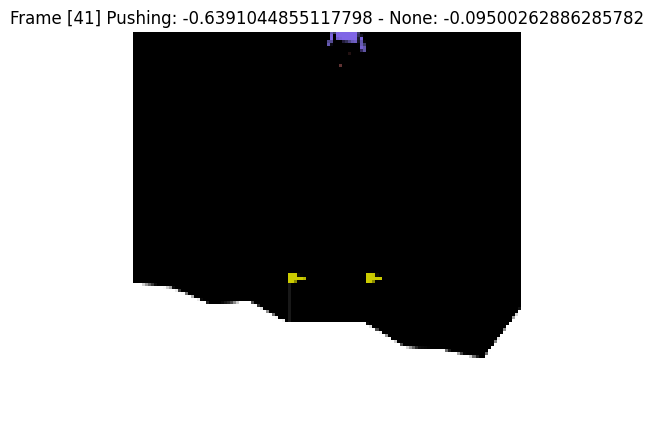

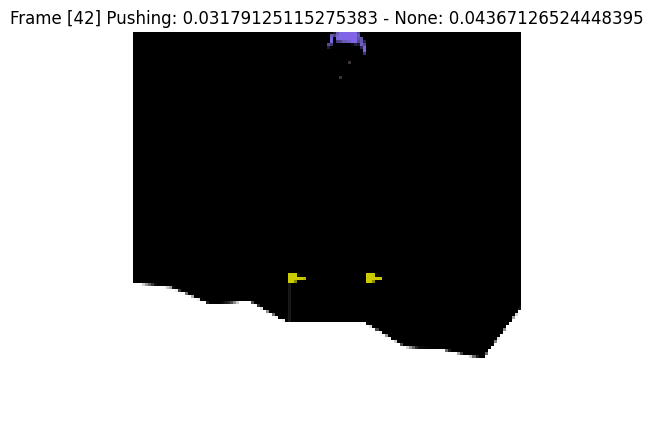

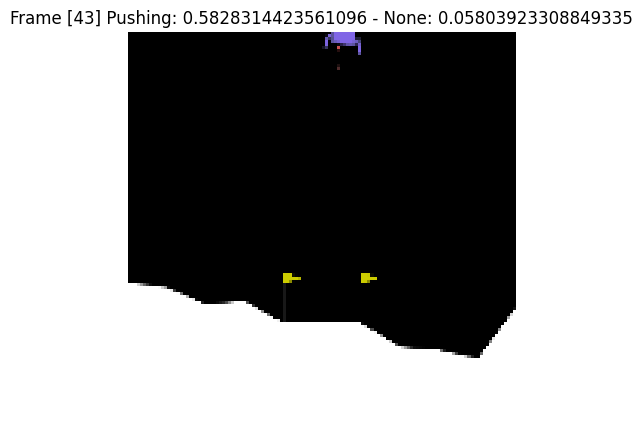

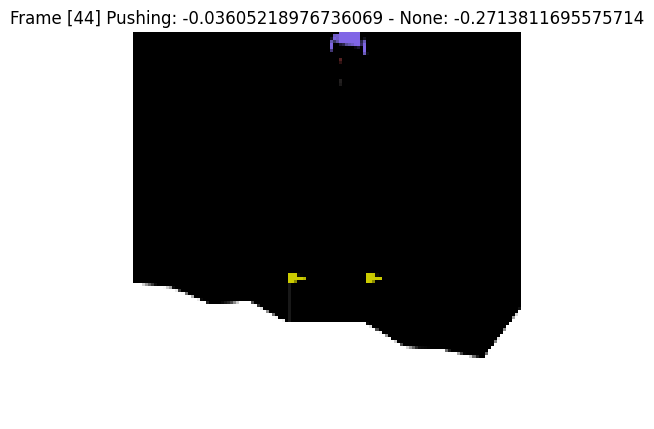

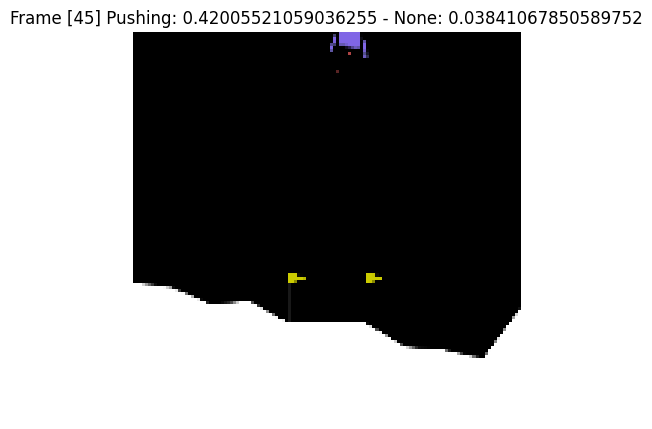

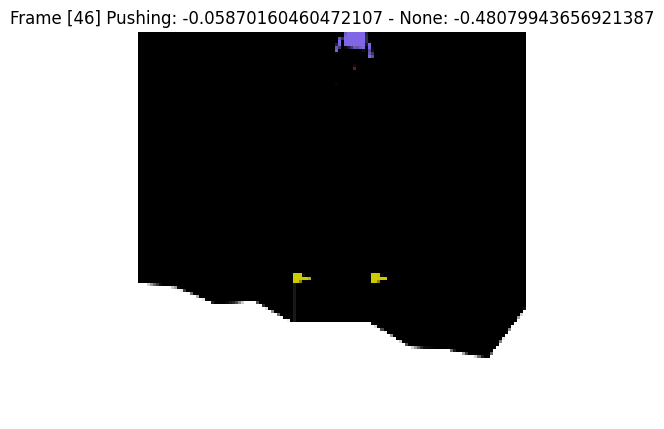

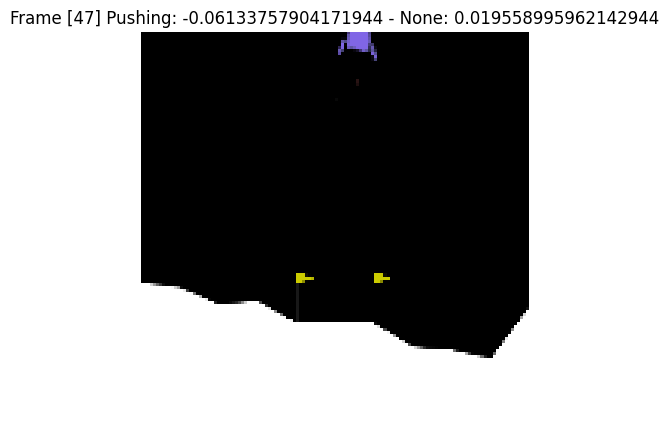

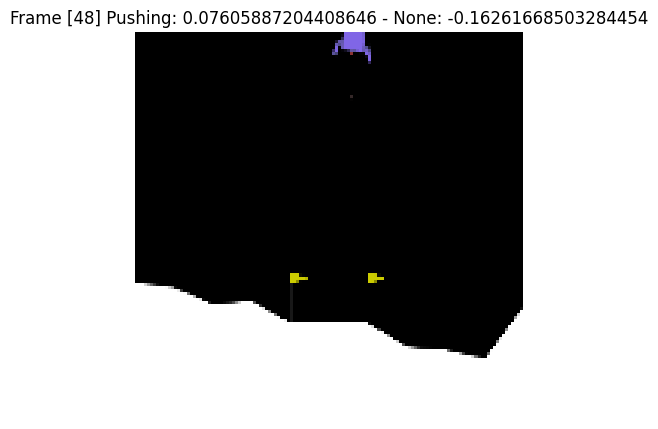

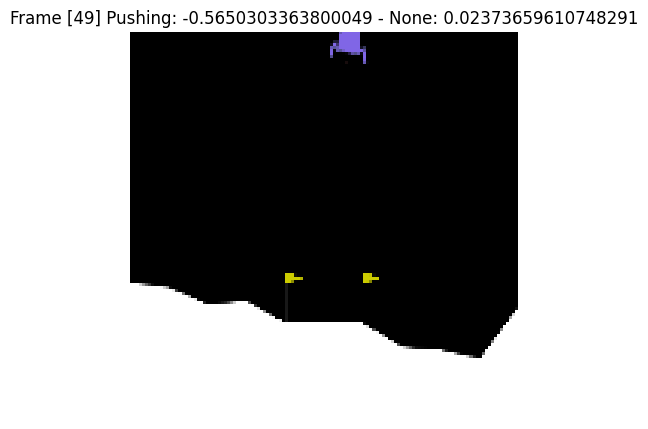

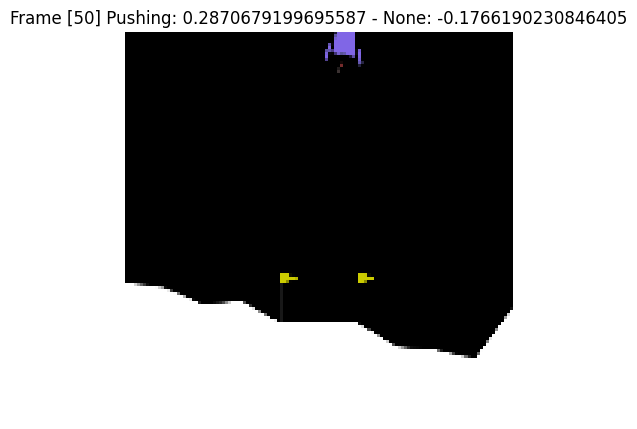

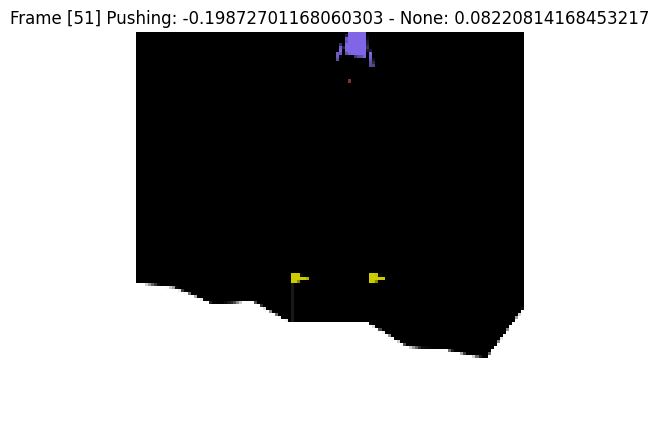

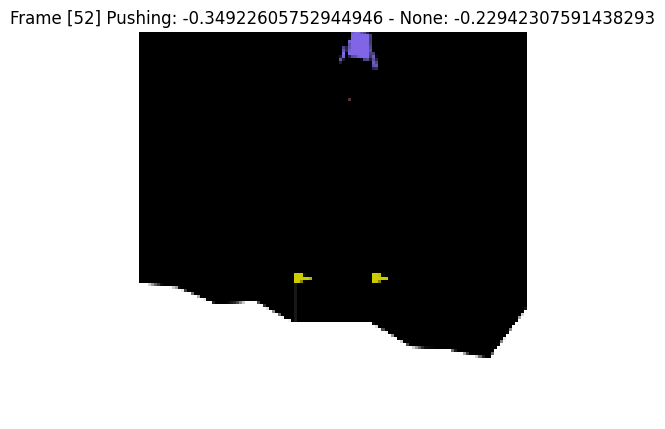

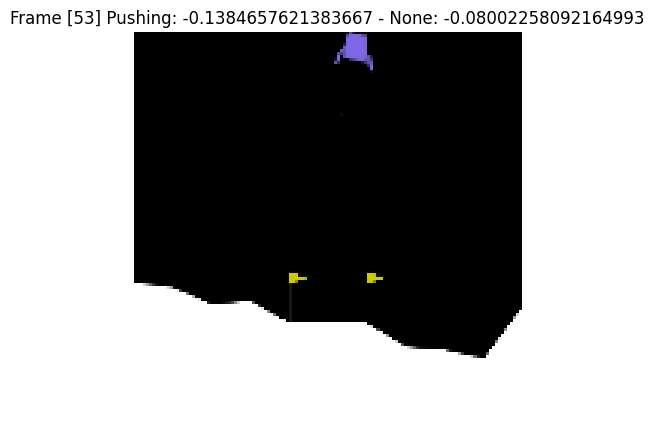

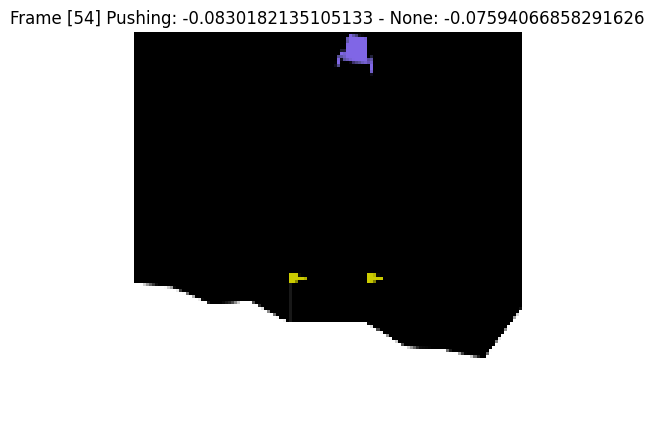

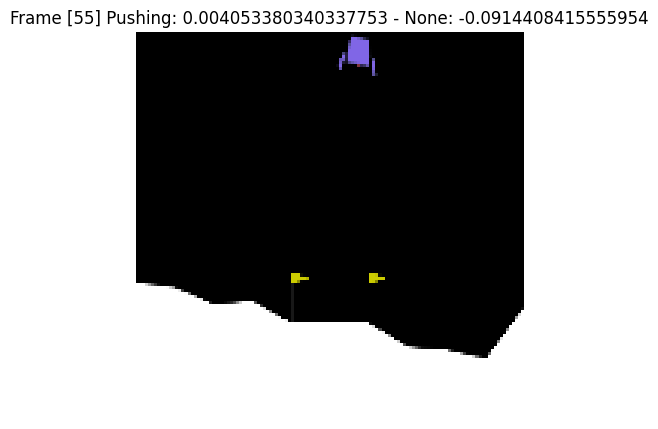

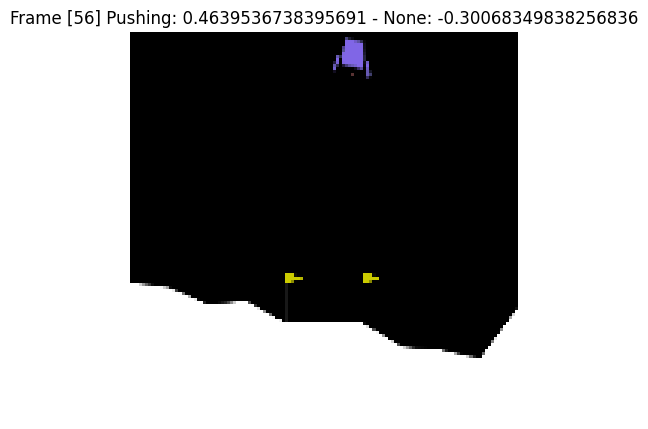

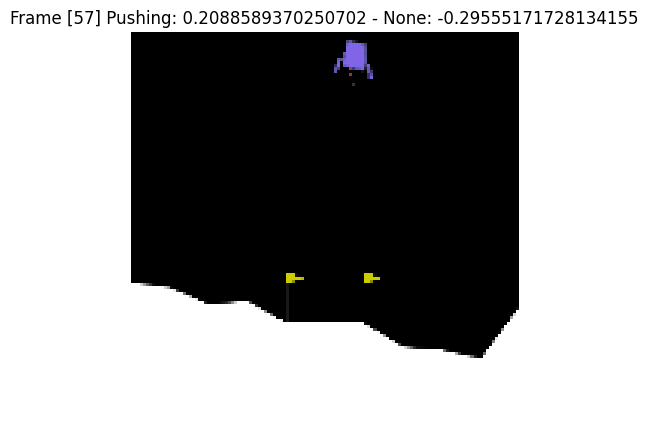

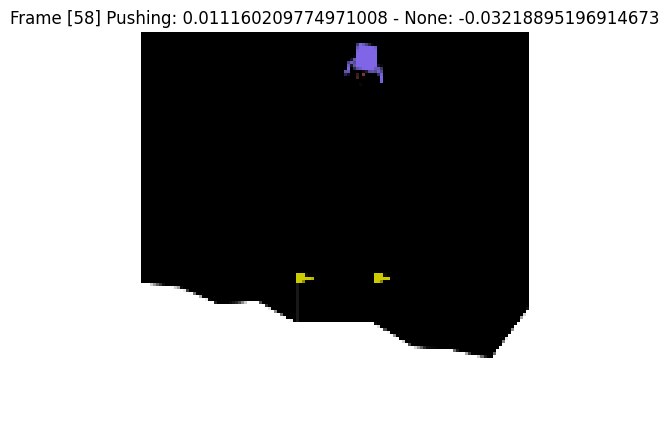

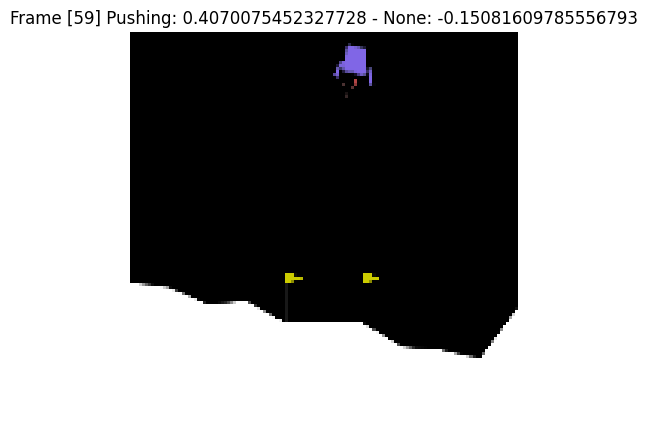

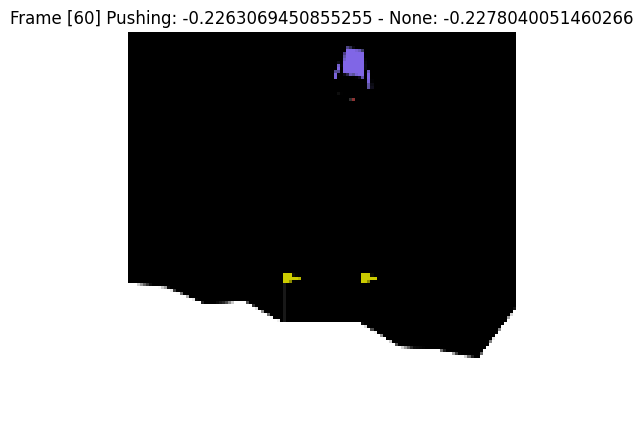

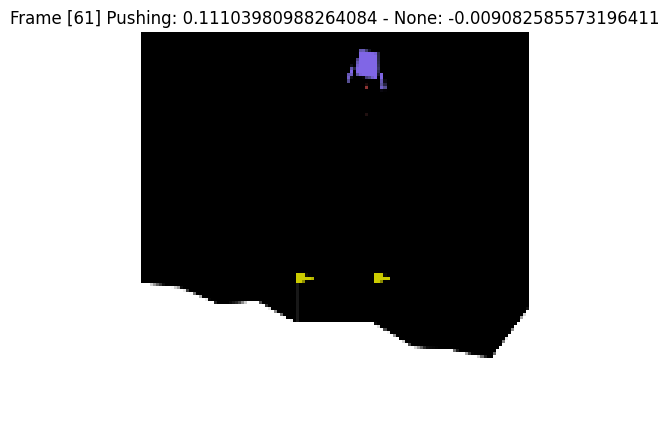

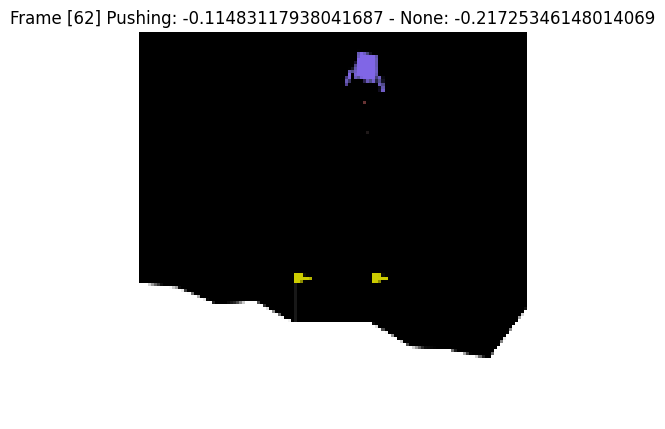

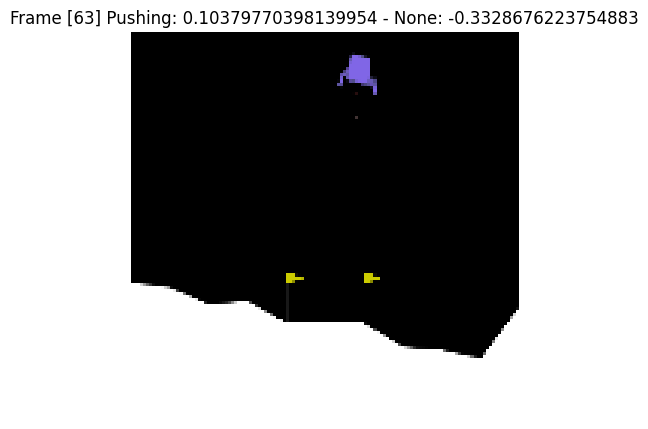

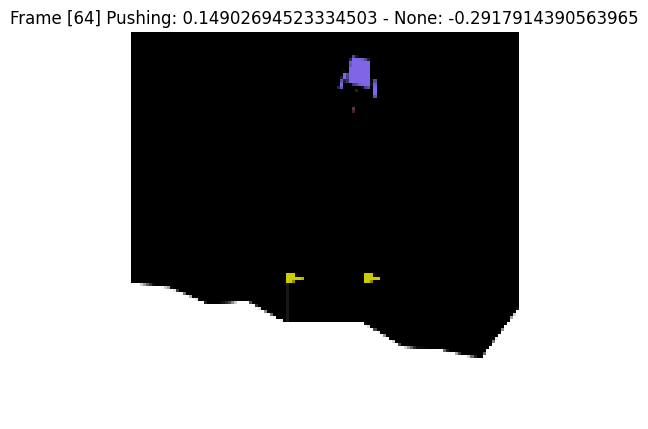

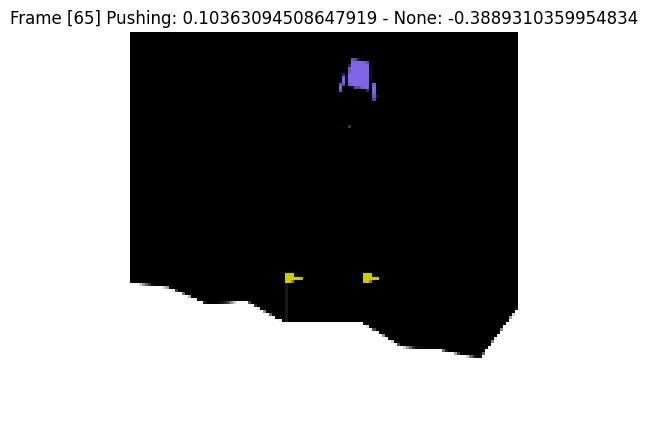

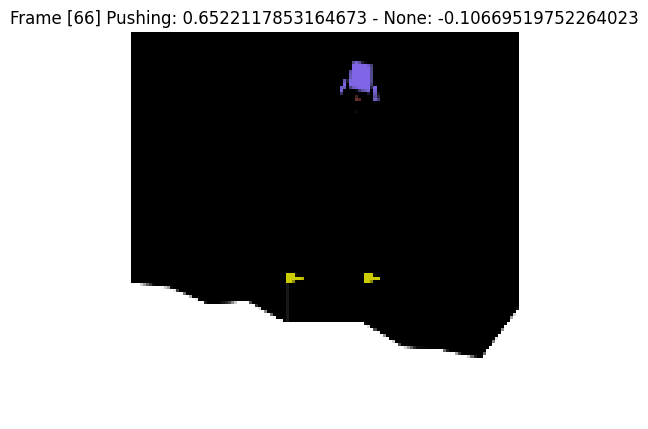

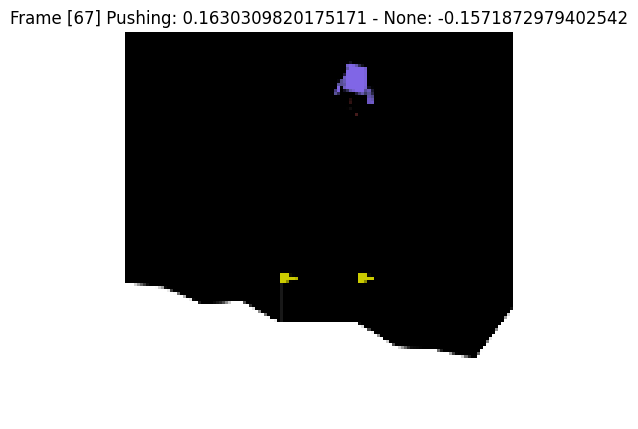

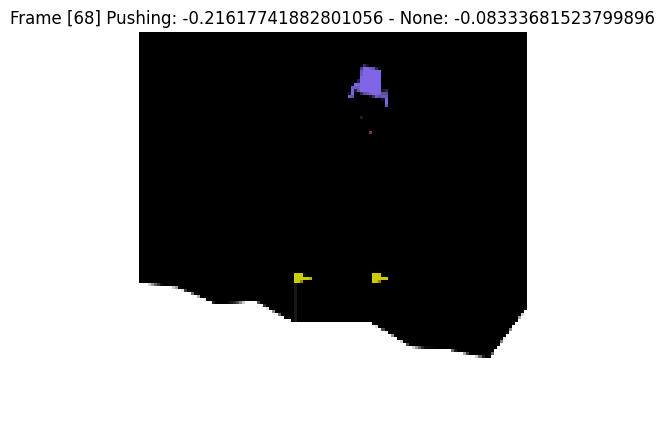

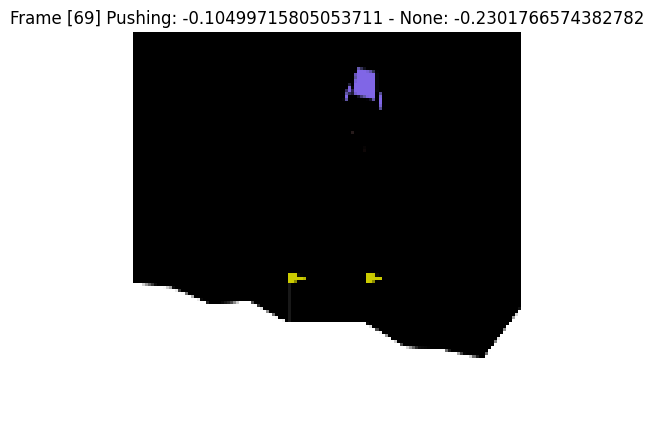

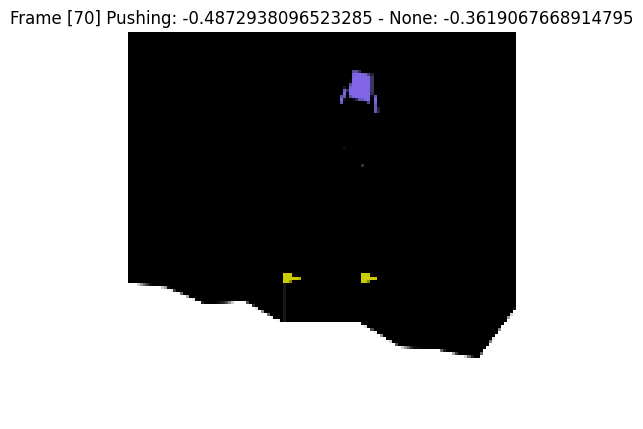

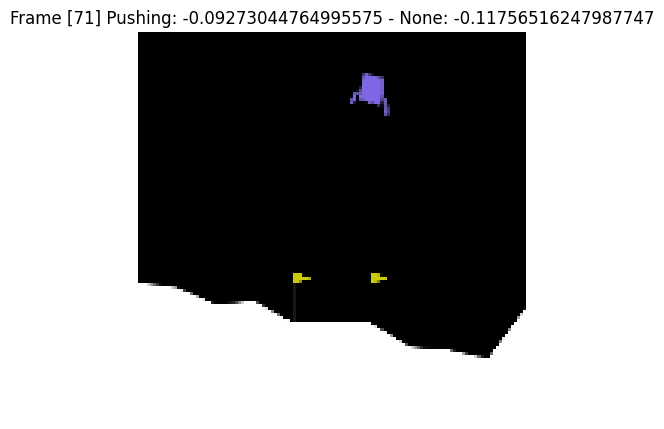

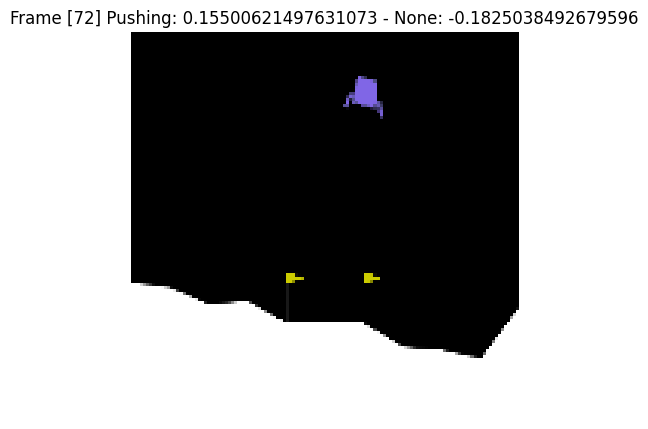

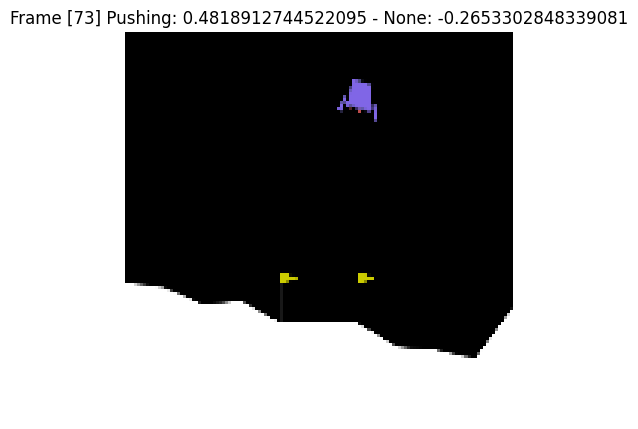

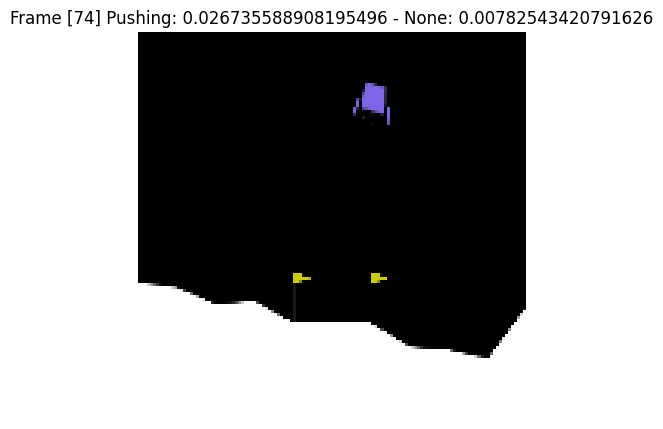

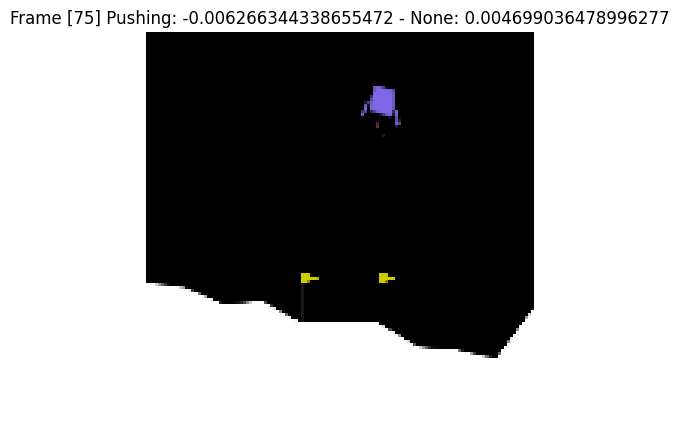

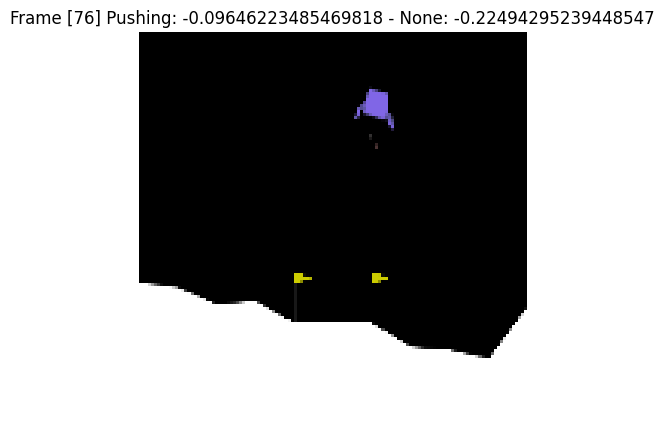

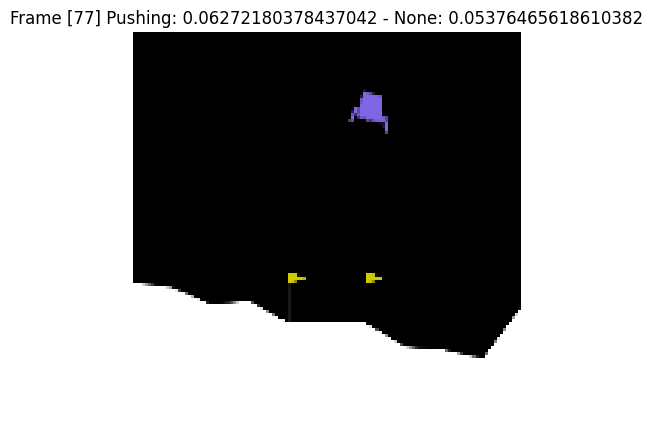

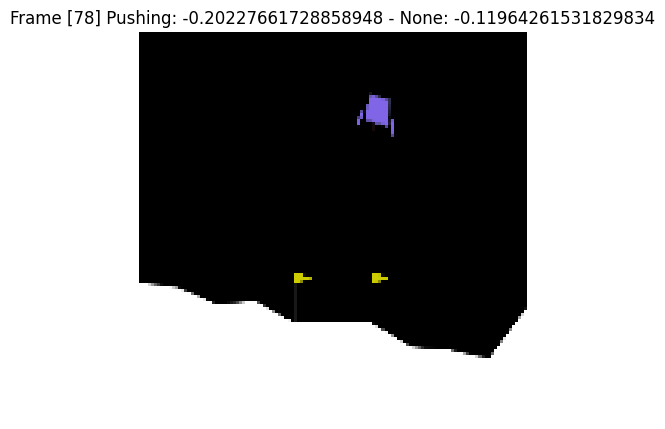

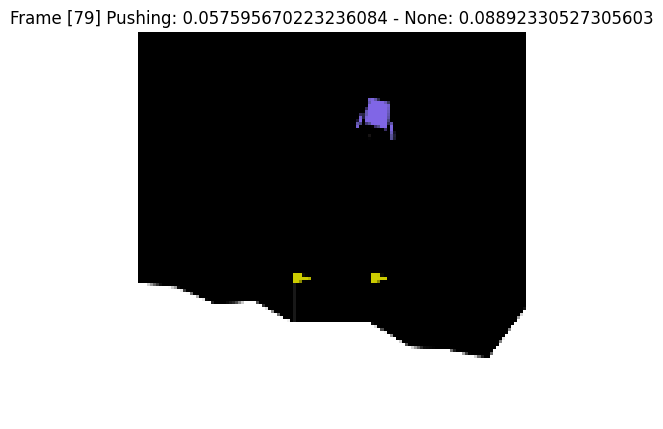

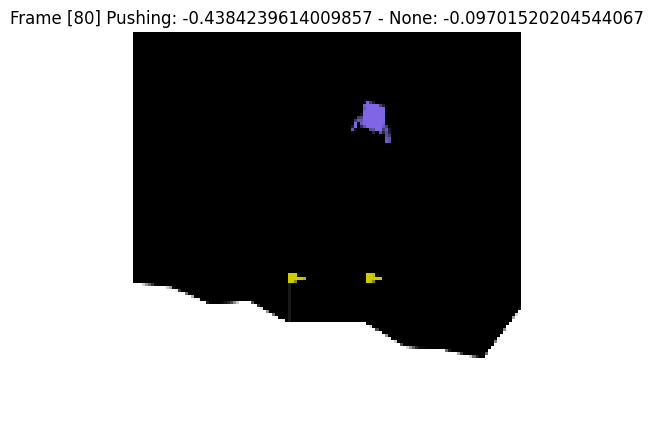

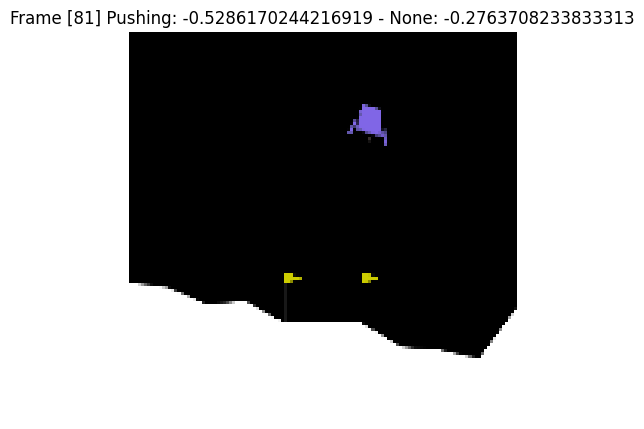

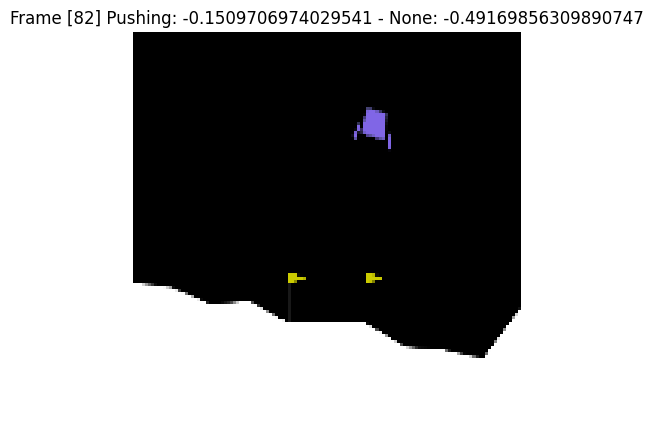

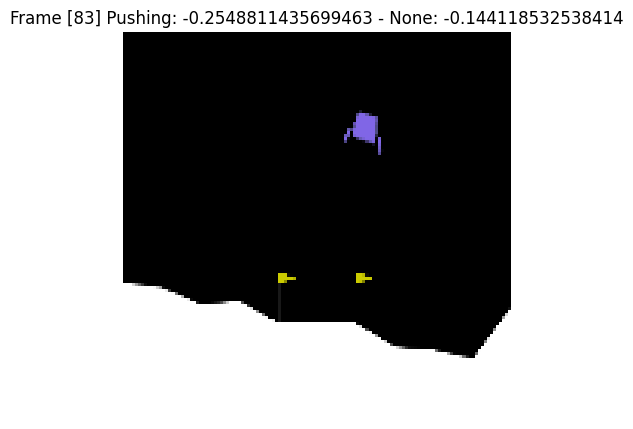

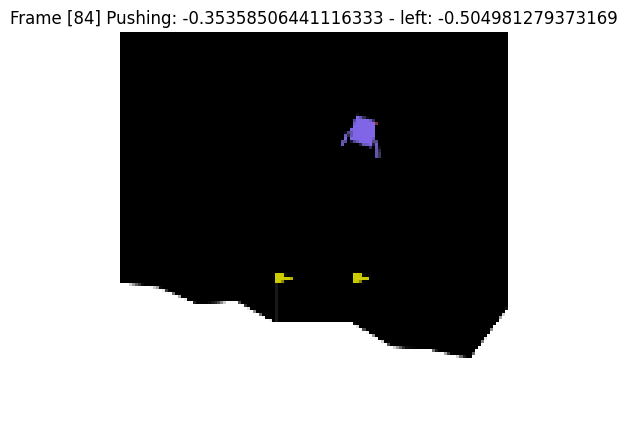

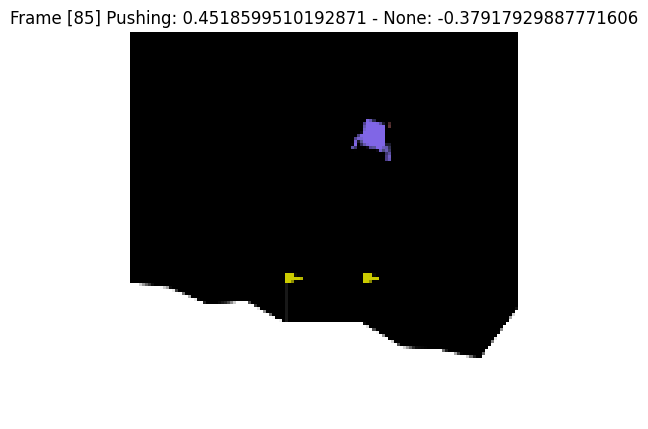

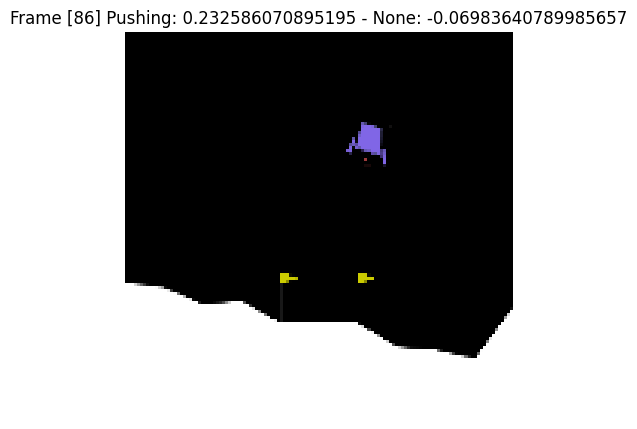

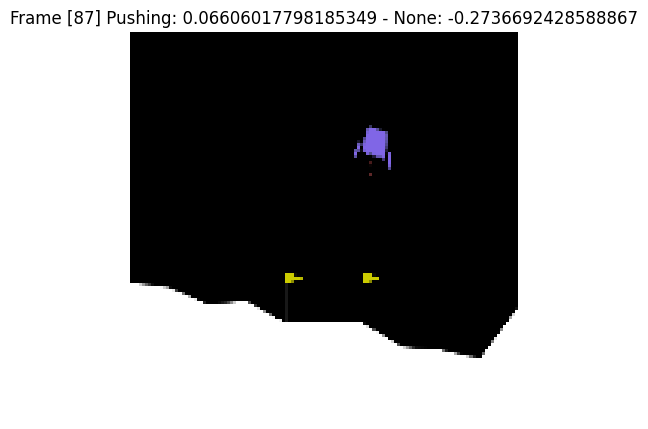

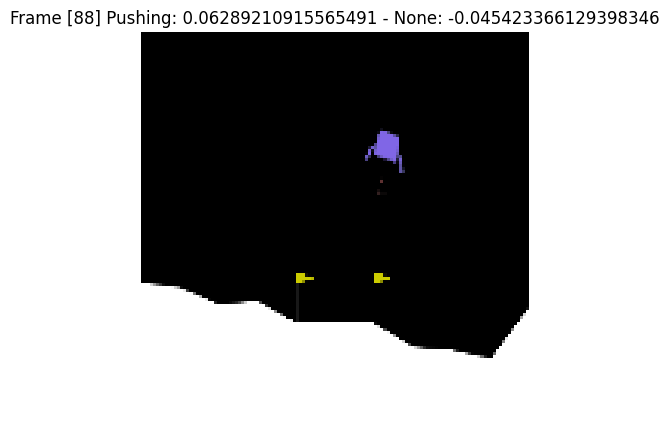

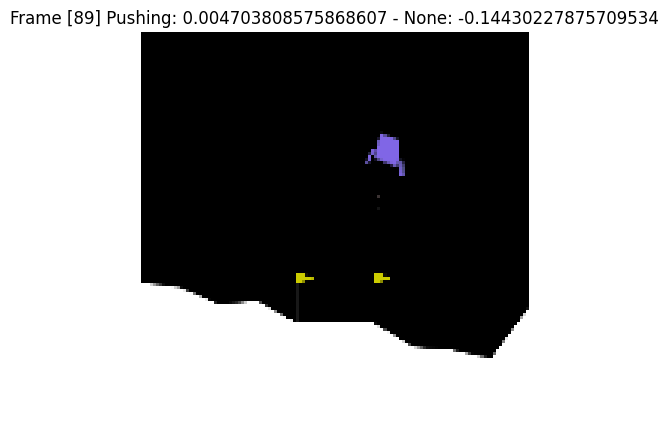

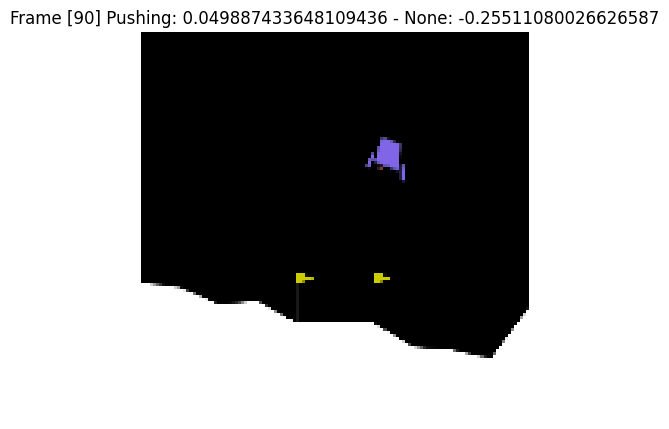

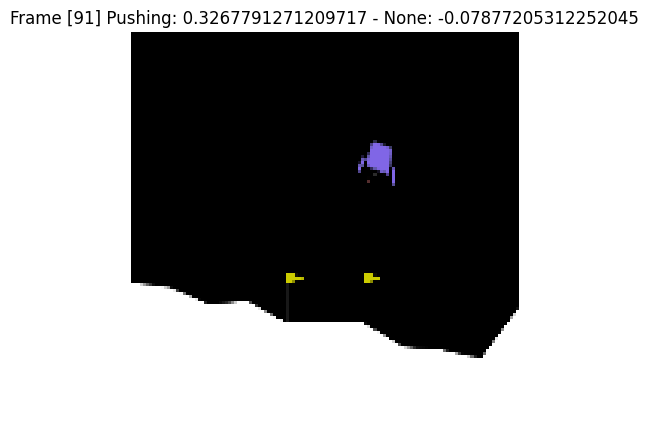

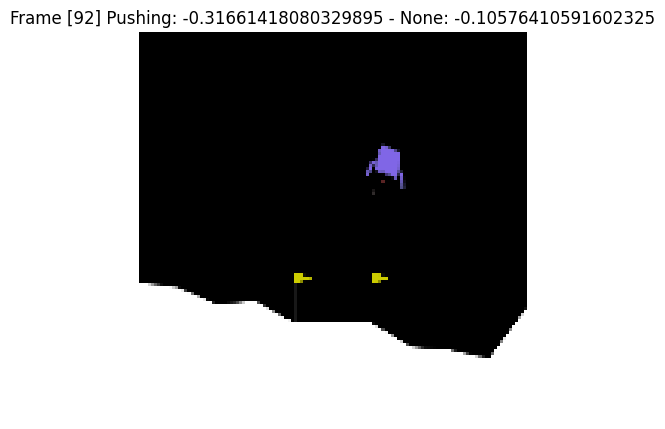

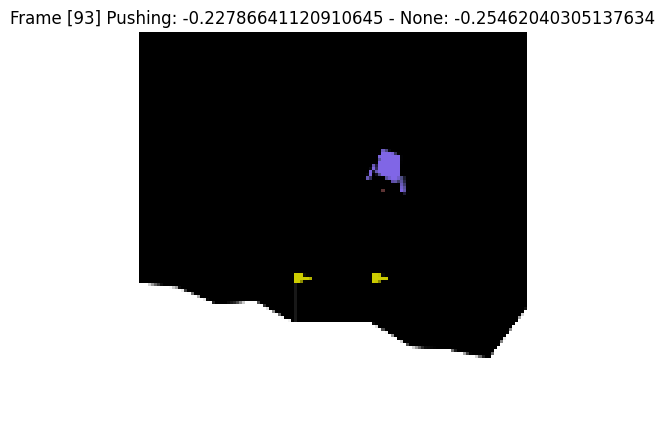

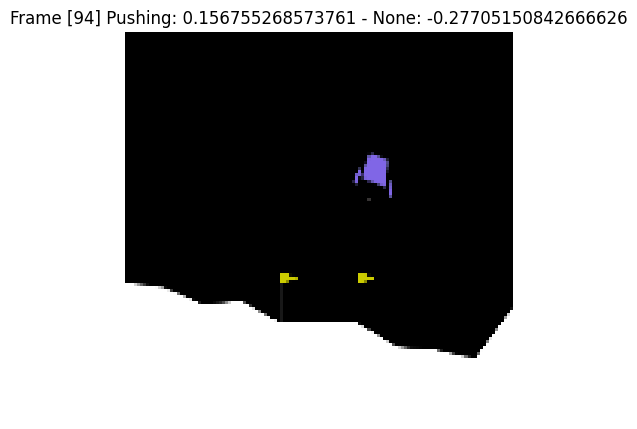

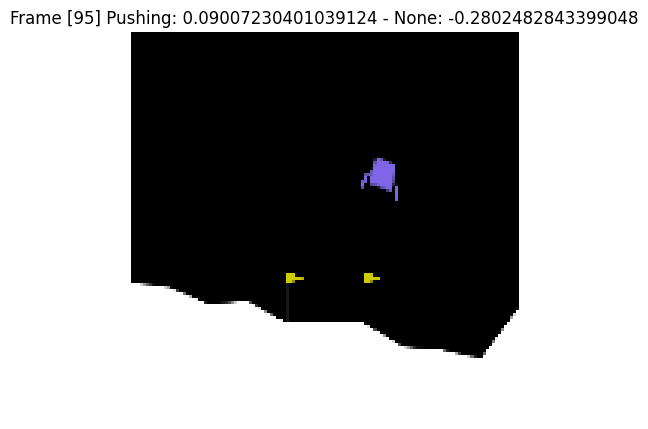

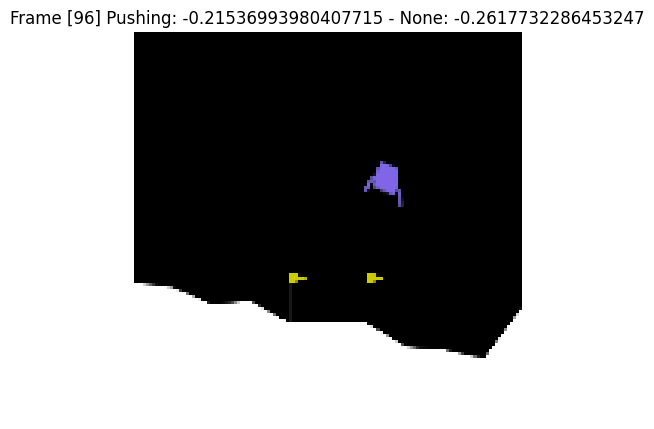

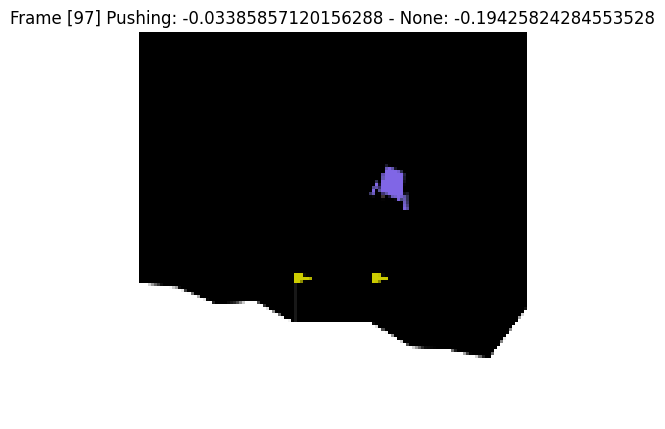

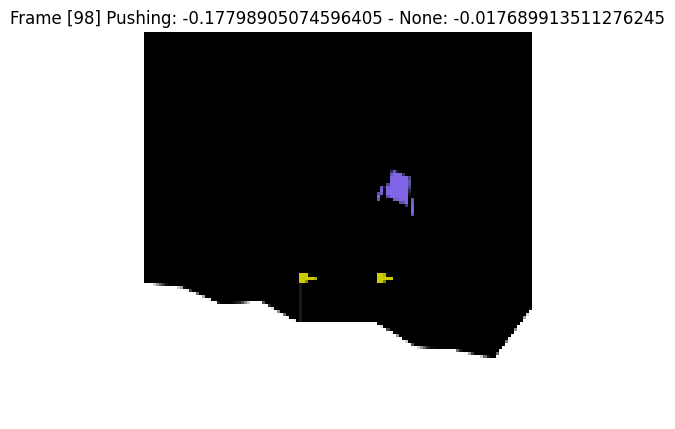

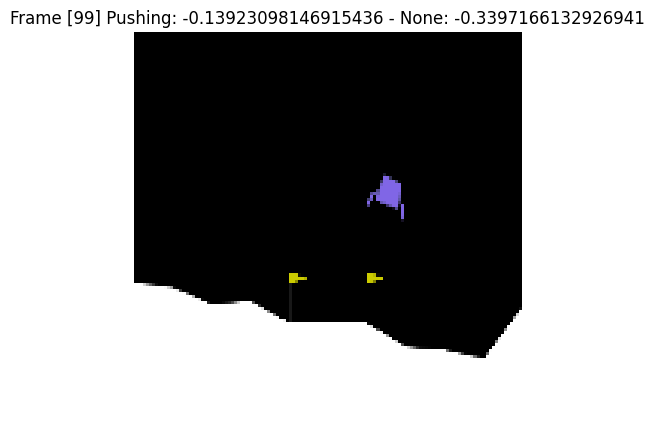

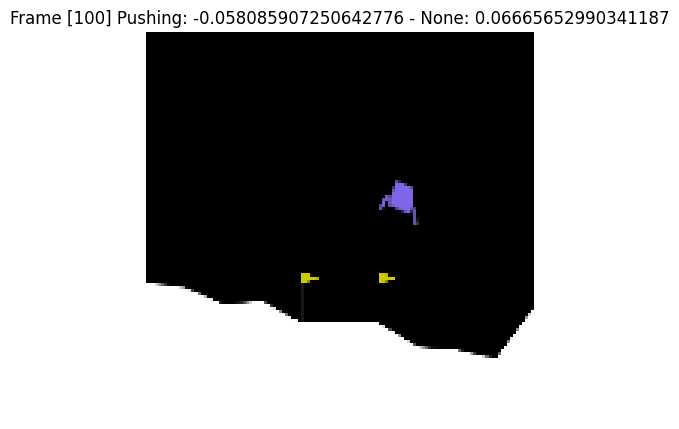

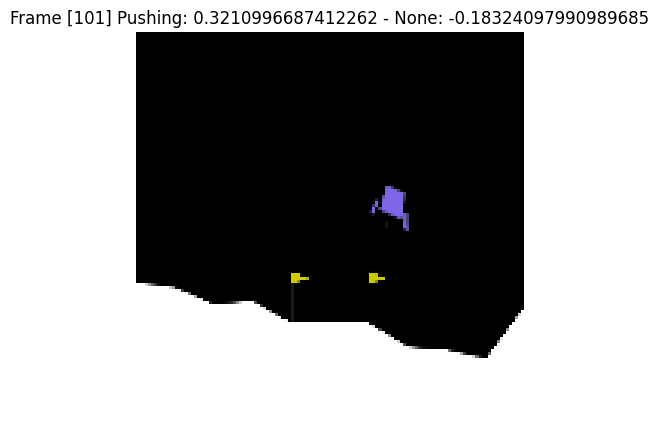

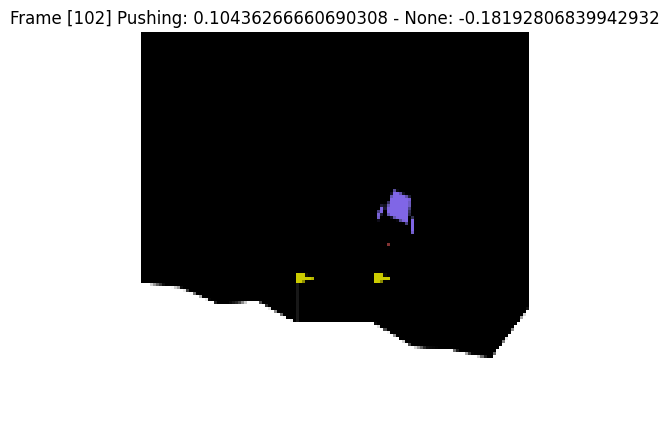

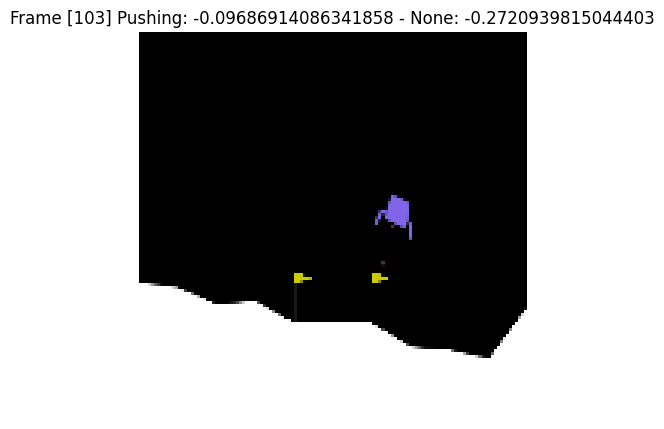

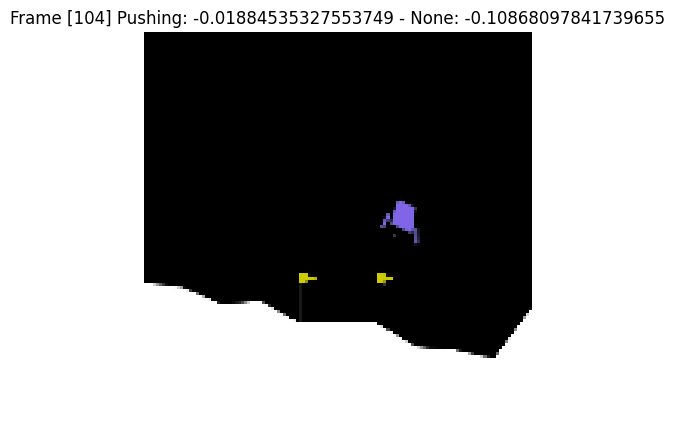

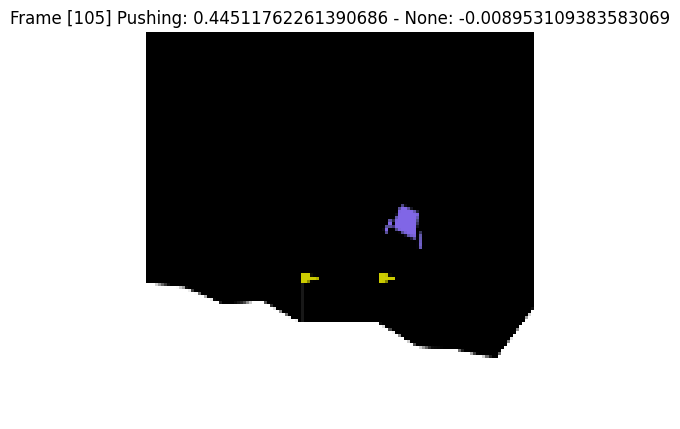

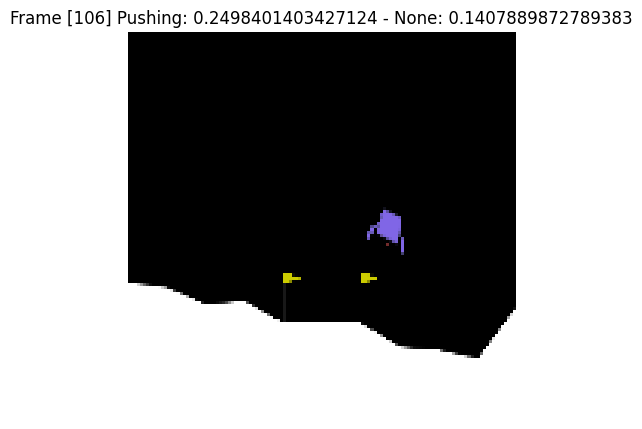

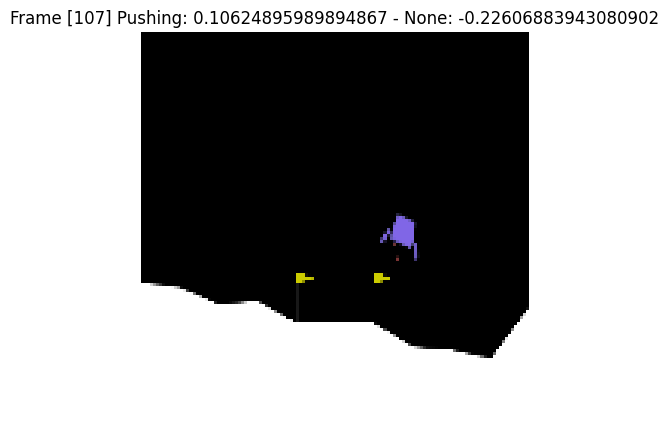

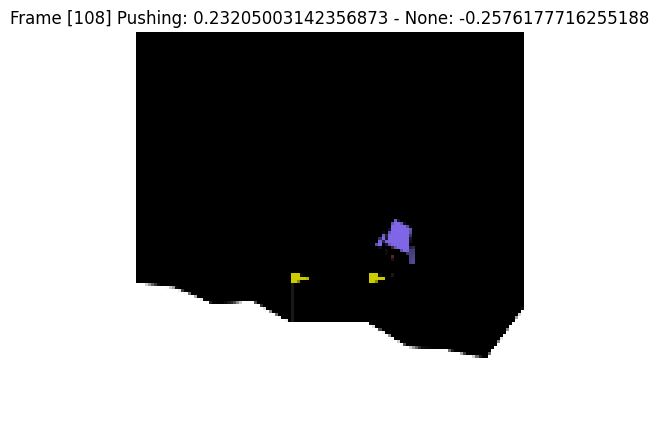

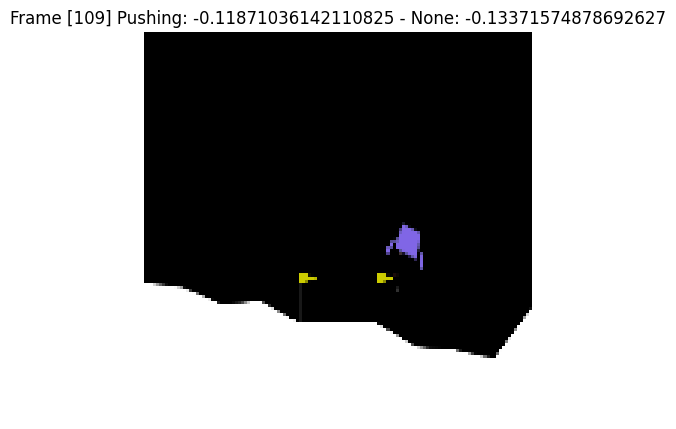

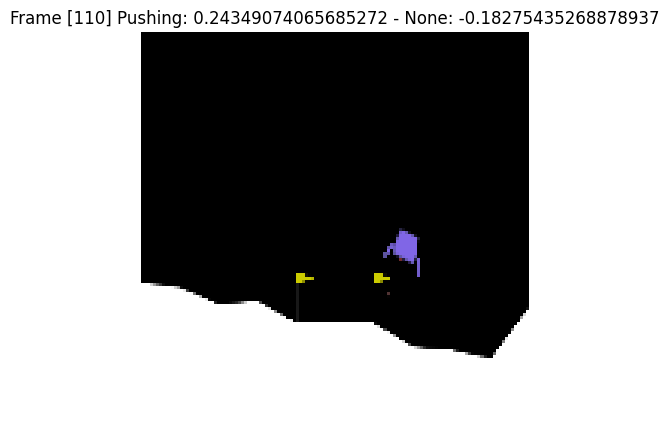

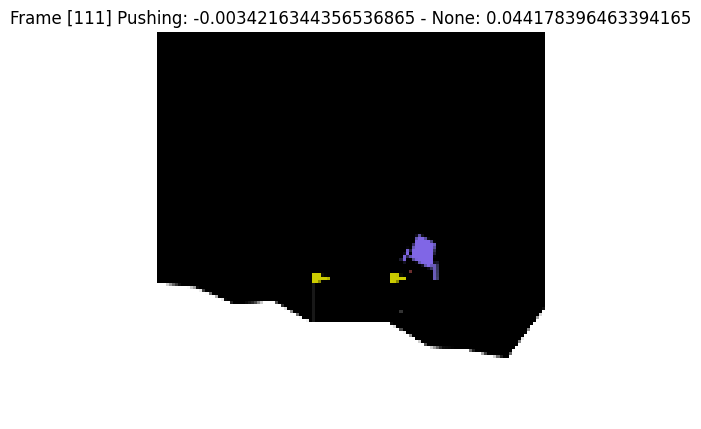

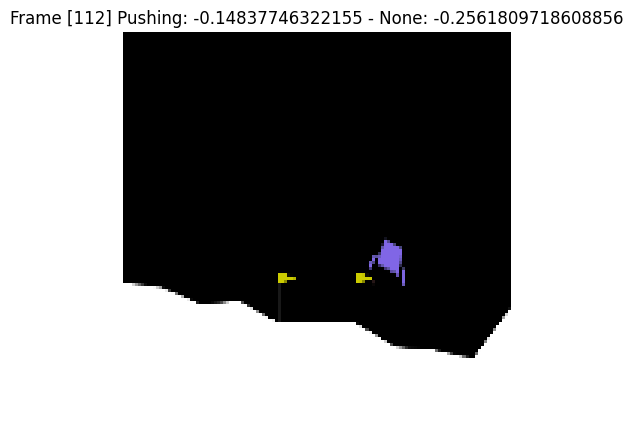

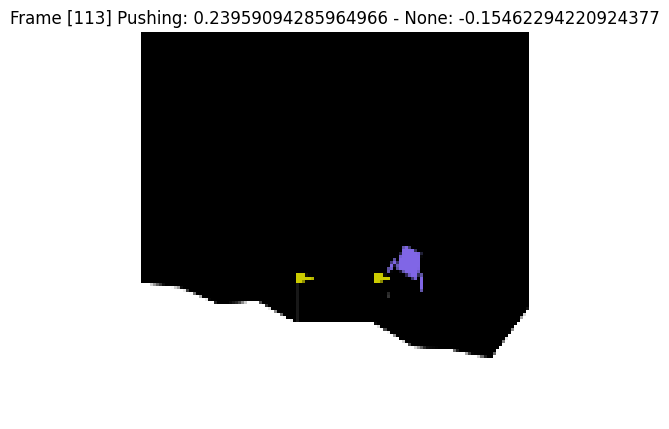

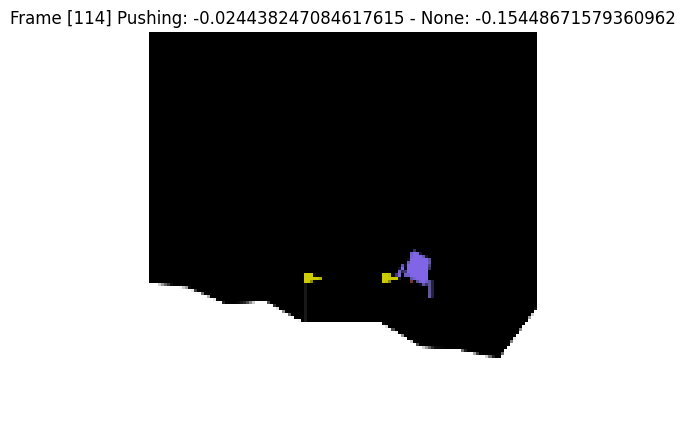

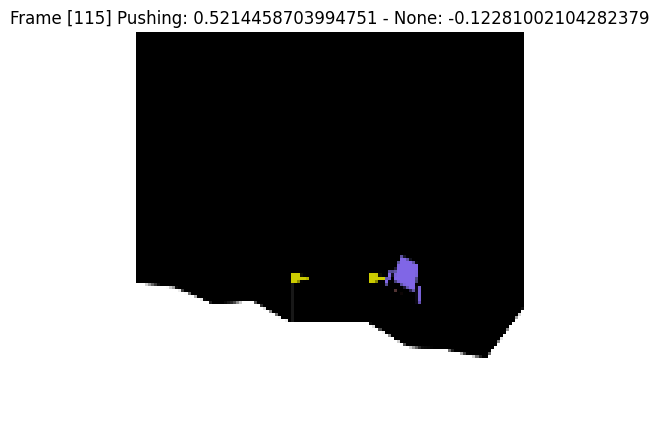

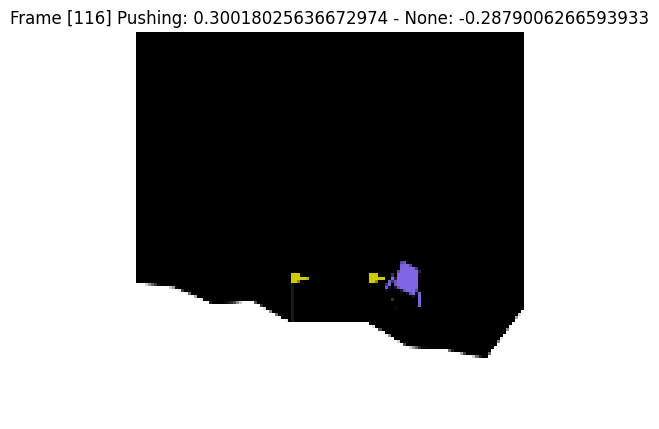

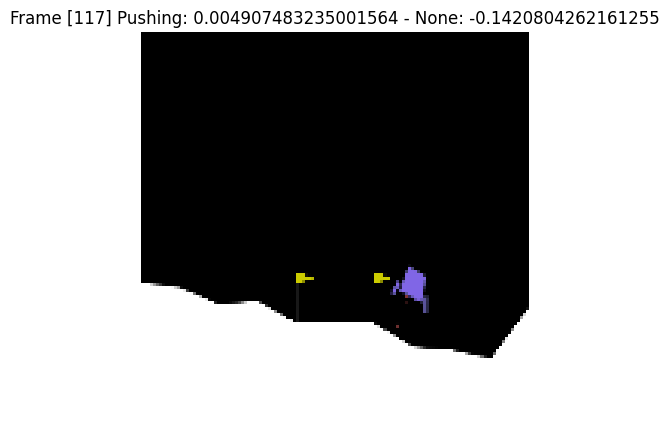

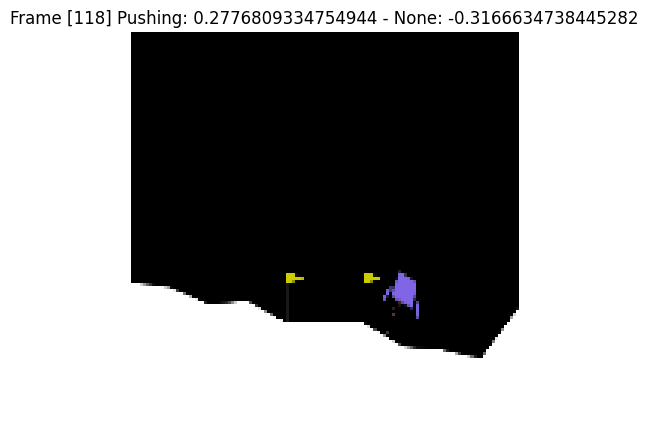

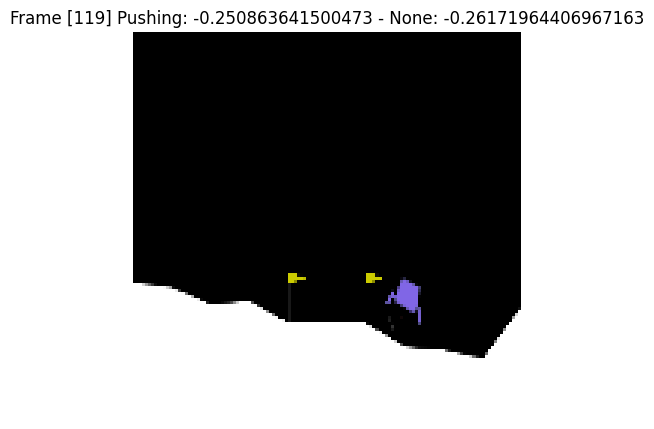

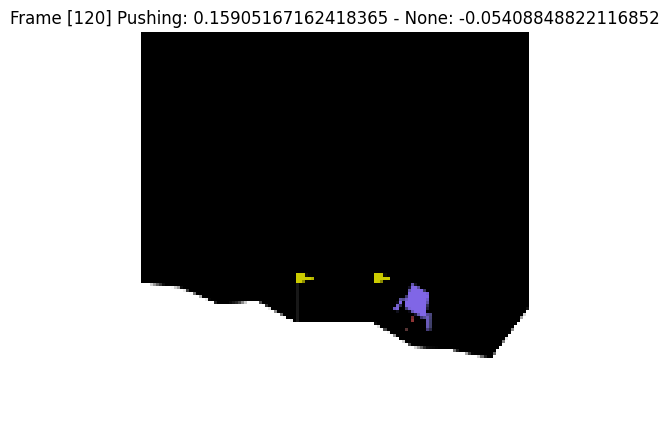

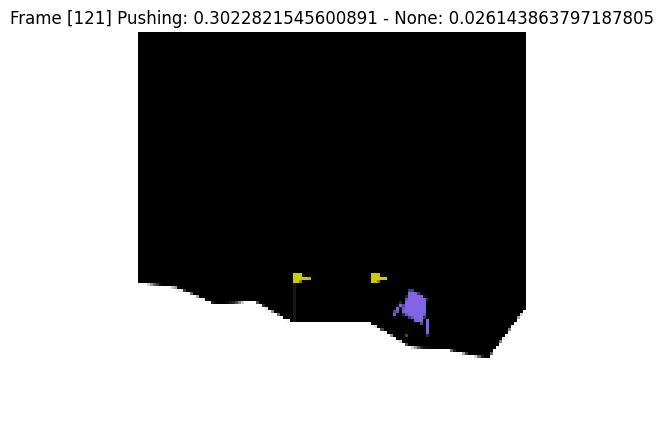

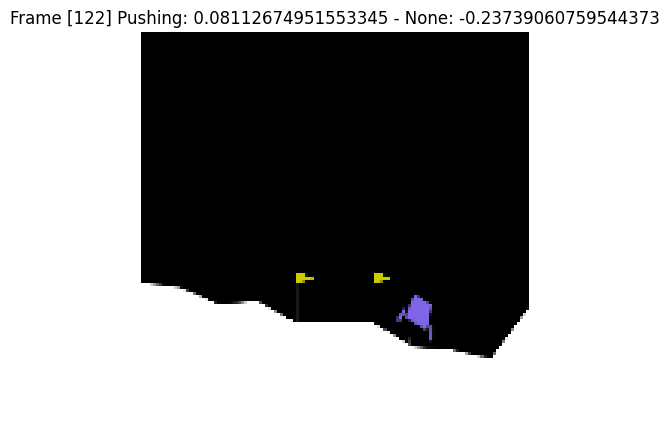

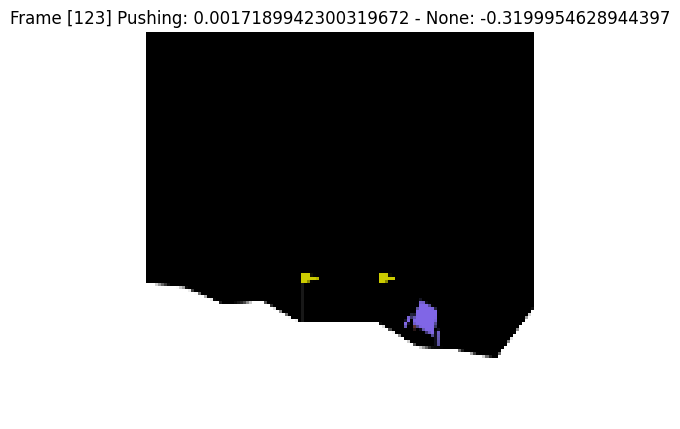

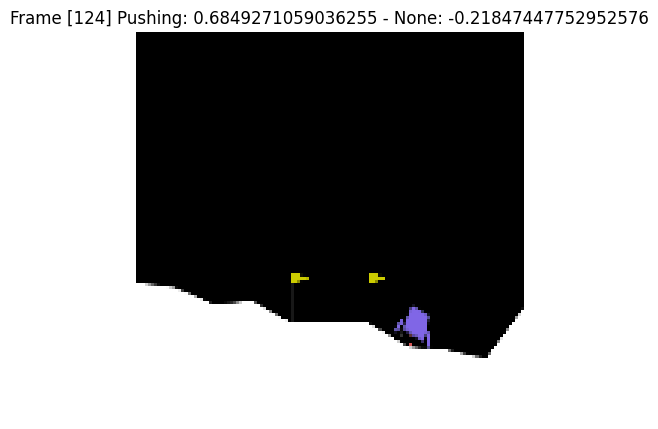

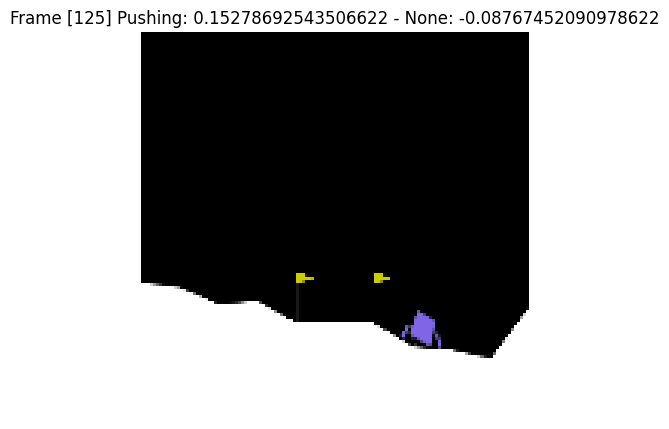

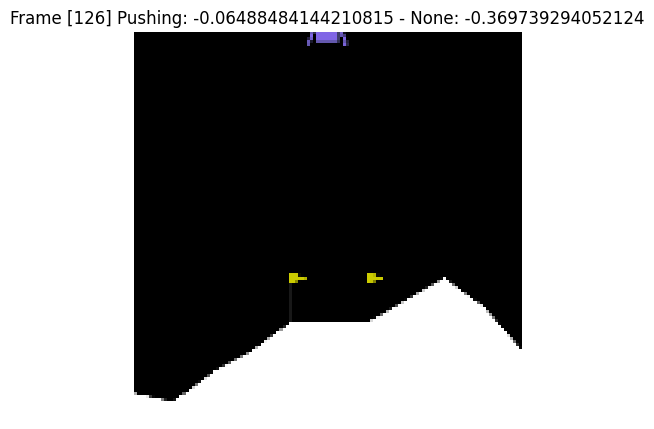

In [8]:
for i in range(len(df)):
    actions = np.squeeze(df.action[i])
    pushing = actions[0]
    side = "None"
    if actions[1] < -0.5:
        side = "left"
    elif actions[1] > 0.5:
        side = "right"
    
    plot_obs(df.state[i], 
             title=f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", 
             n_frame=1)

In [9]:
model_ckpt_2 = "../../run/ppo_vislunarlander_default/artifacts/checkpoints/ppo_vislunarlander_lstm_cnn_4_745472_steps"
model = RecurrentPPO.load(model_ckpt_2)

model

In [10]:
obs.shape

(1, 3, 128, 128)

In [11]:
import torch
import torchinfo

print(torchinfo.summary(model.policy.features_extractor, obs.shape, device="cpu"))
print(model.policy.lstm_actor)
torchinfo.summary(model.policy.lstm_actor, (1, 256), device="cpu")

Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN_4                              [1, 256]                  --
├─Sequential: 1-1                        [1, 15876]                --
│    └─Conv2d: 2-1                       [1, 4, 63, 63]            112
│    └─ReLU: 2-2                         [1, 4, 63, 63]            --
│    └─Flatten: 2-3                      [1, 15876]                --
├─Sequential: 1-2                        [1, 256]                  --
│    └─Linear: 2-4                       [1, 256]                  4,064,512
│    └─ReLU: 2-5                         [1, 256]                  --
Total params: 4,064,624
Trainable params: 4,064,624
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.51
Input size (MB): 0.20
Forward/backward pass size (MB): 0.13
Params size (MB): 16.26
Estimated Total Size (MB): 16.58
LSTM(256, 256)


Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 256]                  526,336
Total params: 526,336
Trainable params: 526,336
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 134.74
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 2.11
Estimated Total Size (MB): 2.11

In [ ]:

def extract_feature(obs):
    model.predict(obs)

    obs_sample = torch.tensor(obs, dtype=torch.float32).to("cpu")
    cnn_model = model.policy.features_extractor

    with torch.no_grad():
        layer_features = cnn_model.get_layer_features(obs_sample)

    return layer_features

layer_features = extract_feature(obs)
layer_features.keys()


IndexError: index 3 is out of range

In [19]:
print(df.state[50].shape)
print(layer_features["layer1"].numpy().shape)
print(layer_features["layer2"].numpy().shape)
print(layer_features["layer3"].numpy().shape)

(1, 3, 128, 128)
(1, 8, 63, 63)
(1, 16, 31, 31)
(1, 16, 15, 15)


In [20]:
torch.manual_seed(10)

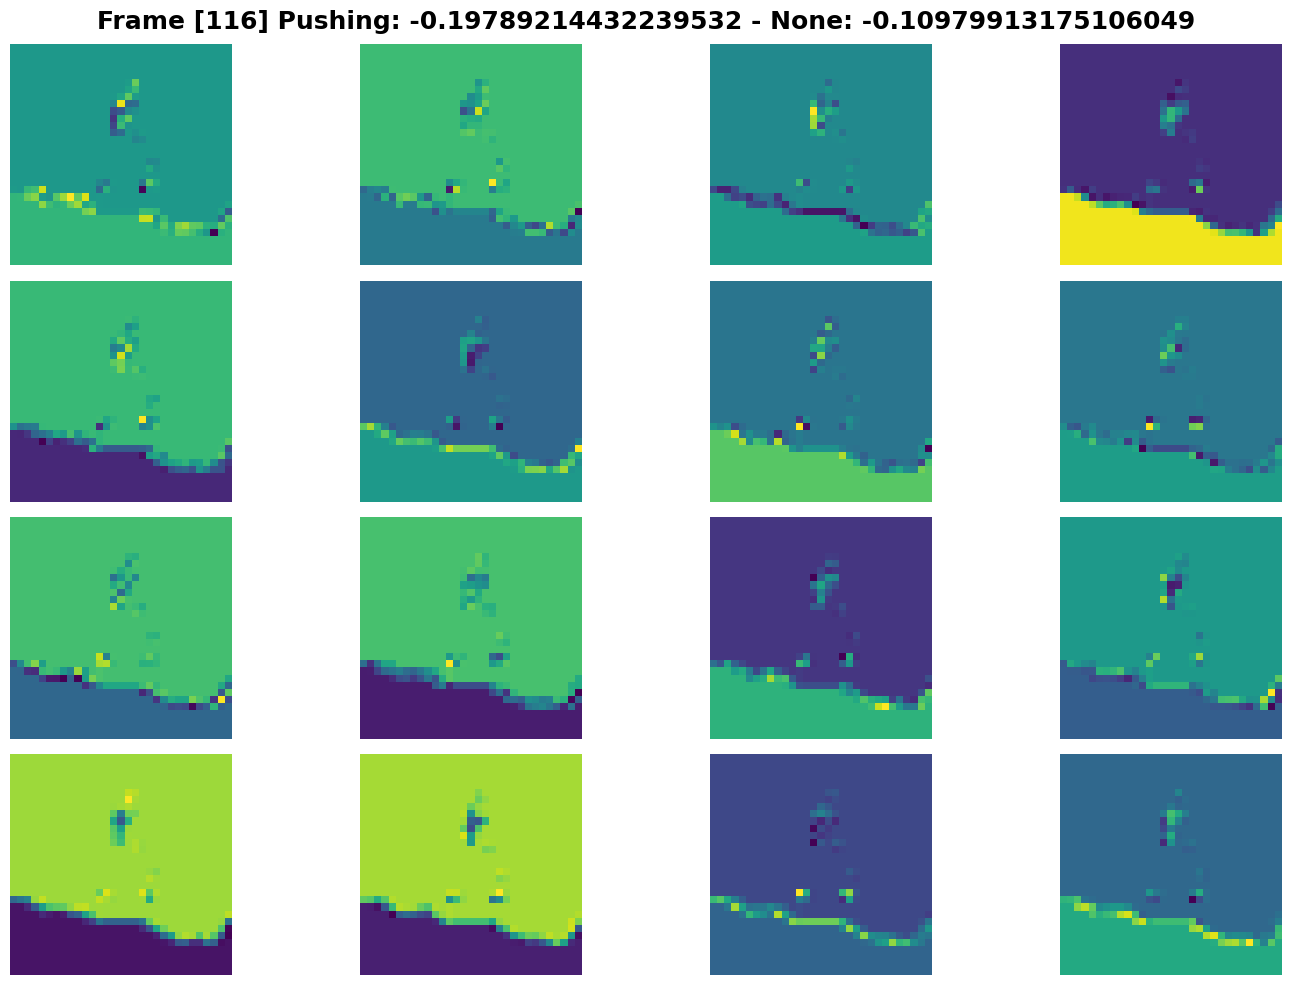

In [57]:
obs = df.state[85]
chosen_layer = "layer2"
layer_features = extract_feature(obs)
layer_features.keys()

nrow = layer_features[chosen_layer].numpy().shape[1]
ncol = np.ceil(nrow/4)
fig, ax = plt.subplots(4, ncol.astype(int), figsize=(15, 10))

for id in range(nrow):
    feature_map = layer_features[chosen_layer][0, id].detach().cpu().numpy()
    ax[int(id/ncol), int(id%ncol)].imshow(feature_map, cmap="viridis")
    ax[int(id/ncol), int(id%ncol)].axis("off")

actions, _ = model.predict(obs, deterministic=1)
actions = np.squeeze(actions)
pushing = actions[0]
side = "None"
if actions[1] < -0.5:
    side = "left"
elif actions[1] > 0.5:
    side = "right"

fig.suptitle(f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", fontsize=18, fontweight='bold')
plt.tight_layout()


# Check model parameters

In [22]:
from src.model.cnn import CustomCNN_2

In [ ]:
policy_kwargs = dict(
    features_extractor_class=CustomCNN_2,
    features_extractor_kwargs=dict(features_dim=256, num_frames=4)  # Adjust num_frames as needed
)

# Create the PPO agent using the custom feature extractor
checking_model = PPO(
    "CnnPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
)

summary(checking_model.policy.features_extractor, obs[0].shape)

NameError: name 'PPO' is not defined